#**CAPSTONE PROJECT**| **INSURANCE CUSTOMER RESPONSE PREDICTION**

---





---

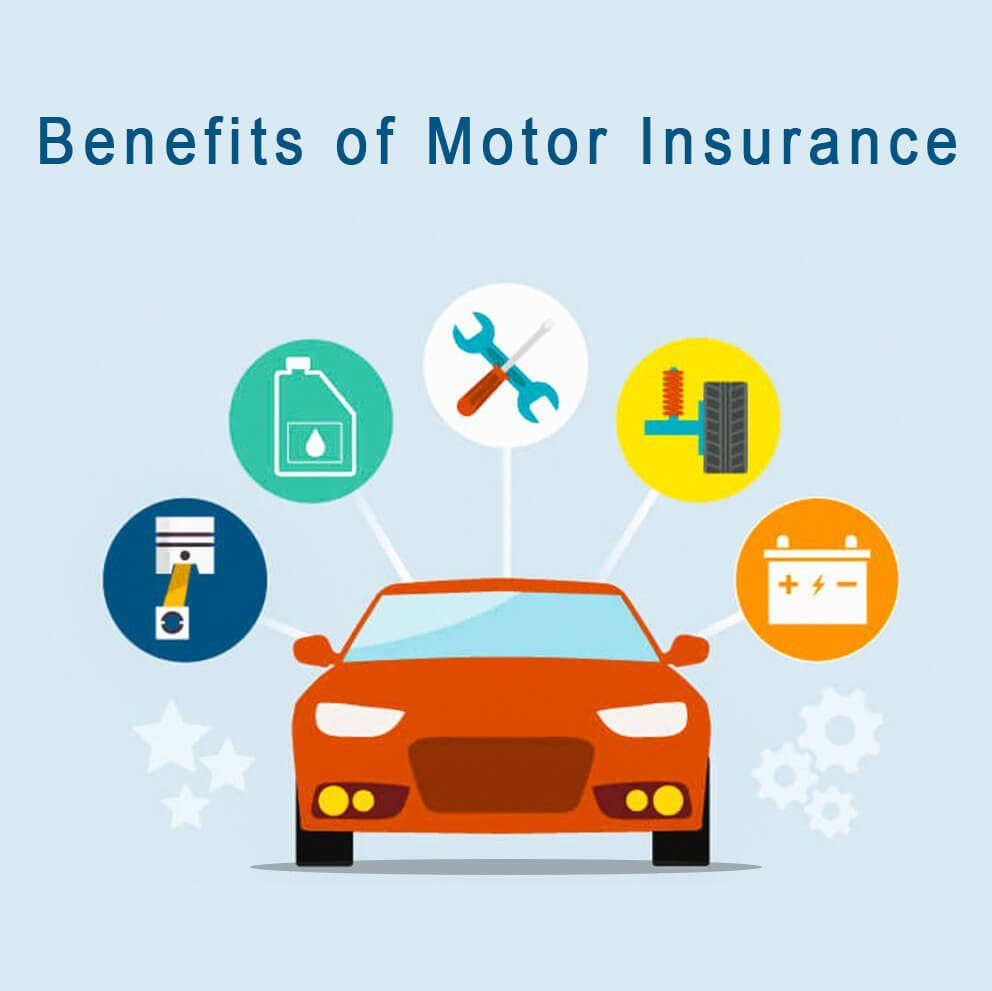

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left"> <h3 align="left"><font color=red>Problem:</font></h3>

In this project, we explore a dataset containing various customer and vehicle-related attributes, such as age, driving license status, vehicle age, vehicle damage history, premium amount, and more.
Our objective is to build a predictive model that can accurately determine whether a customer is likely to respond positively to a health insurance policy offer.

Since converting interested customers is crucial for business growth, and missing a potential buyer can result in revenue loss, our primary focus is on ensuring that the model correctly identifies all customers who are likely to respond. Therefore, recall for the positive class (Response = 1) becomes an essential evaluation metric for this project.

</div>

<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Table of Contents:</font></h3>
    
* [Step 1 | Import Libraries](#import)
* [Step 2 | Read Dataset](#read)
* [Step 3 | Dataset Overview](#overview)
    - [Step 3.1 | Dataset Basic Information](#basic)
    - [Step 3.2 | Summary Statistics for Numerical Variables](#num_statistics)
    - [Step 3.3 | Summary Statistics for Categorical Variables](#cat_statistics)
* [Step 4 | EDA](#eda)
    - [Step 4.1 | Bivariate Analysis](#Bivariate)
        - [Step 4.1.1 | Numerical Variables Bivariate Analysis](#num_uni)
        - [Step 4.1.2 | Categorical Variables Bivariate Analysis](#cat_uni)
    - [Step 4.2 | Univariate Analysis](#univariate)
        - [Step 4.2.1 | Numerical Variables Univariate Analysis](#num_uni)
        - [Step 4.2.2 | Categorical Variables Univariate Analysis](#cat_uni)
    -
* [Step 5 | Data Preprocessing](#preprocessing)
    - [Step 5.1 | Missing Value Treatment](#missing)
    - [Step 5.2 | Outlier Treatment](#outlier)
    - [Step 5.3 | Categorical Features Encoding & Feature Scaling](#encoding)
* [Step 6 | Logistic Regression Building](#Logistic)
    - [ DT Base Model Definition](#svm_base)
    - [ DT Model Evaluation](#svm_eval)    
* [Step 7 | Decision Tree Model Building](#dt)
    - [ DT Base Model Definition](#dt_base)
    - [ DT Model Evaluation](#dt_eval)
* [Step 8 | Random Forest Model Building](#rf)
    - [ RF Base Model Definition](#rf_base)
    - [ RF Model Evaluation](#rf_eval)
* [Step 9 | Ada Boost Model Building](#ada)
    - [ Ada Base Model Definition](#ada_base)
    - [ Ada Model Evaluation](#ada_eval)
* [Step 10 | XGBoost Model Building](#XG Boost)
    - [ XG Boost Base Model Definition](#XG Boost_base)
    - [ XG Boost Model Evaluation](#XG Boost_eval)
* [Step 11 | XGBoost ROC - AUC CURVE](#roc-auc)
* [Step 12 | Model Comparison](#mc)
* [Step 13 | XGBOOST Test & Train Score](#XG Boost)
* [Step 14 | Save The MOdel](#save)
* [Step 15 | Conclusion](#conclusion)


<h2 align="left"><font color=Red>Let's get started:</font></h2>

<a id="import"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

⬆️ [Table of Contents](#contents_tabel)





In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib
import warnings
import time
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set(style="whitegrid")


<a id="read"></a>
# <p style="background-color:red ; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

⬆️ [Table of Contents](#contents_tabel)

In [3]:
df=pd.read_csv("/content/drive/MyDrive/Insurance_Response.csv")
# Loads the dataset from a CSV file named data.csv into a pandas DataFrame (insurance_cust

df.head()
# Displays the dataset

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28,0,> 2 Years,Yes,40454,26,217,1
1,2,Male,76,1,3,0,1-2 Year,No,33536,26,183,0
2,3,Male,47,1,28,0,> 2 Years,Yes,38294,26,27,1
3,4,Male,21,1,11,1,< 1 Year,No,28619,152,203,0
4,5,Female,29,1,41,1,< 1 Year,No,27496,152,39,0


<a id="import"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset overview </p>



<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 3.1 |</span><span style='color:red'> Dataset Basic Information</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">
    
Next, I'll delve into a detailed exploration of the dataset:

In [4]:
# Display a concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    381109 non-null  int64 
 1   Gender                381109 non-null  object
 2   Age                   381109 non-null  int64 
 3   Driving_License       381109 non-null  int64 
 4   Region_Code           381109 non-null  int64 
 5   Previously_Insured    381109 non-null  int64 
 6   Vehicle_Age           381109 non-null  object
 7   Vehicle_Damage        381109 non-null  object
 8   Annual_Premium        381109 non-null  int64 
 9   Policy_Sales_Channel  381109 non-null  int64 
 10  Vintage               381109 non-null  int64 
 11  Response              381109 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 34.9+ MB


<div style="border-radius:10px; padding:15px; background-color:#ffe8e5; font-size:110%;">

<h3 style="color:#c62828;">Dataset Inference</h3>

<ul>
  <li>The dataset contains <b>381,109 customer records</b>, each representing an insurance customer's information.</li>
  
  <li>There are <b>12 features</b> in total, covering customer demographics, vehicle details, and insurance-related attributes.</li>
  
  <li><b>No missing values</b> are present — every column contains complete data.</li>
  
  <li>The dataset includes:
    <ul>
      <li><b>9 numerical columns</b> (Age, Annual_Premium, Vintage, etc.)</li>
      <li><b>3 categorical columns</b> (Gender, Vehicle_Age, Vehicle_Damage)</li>
    </ul>
  </li>
  
  <li>The target variable <b>"Response"</b> is binary (0 = Not Interested, 1 = Interested).</li>
  
  <li>Overall, the dataset is clean, structured, and ready for preprocessing and modeling.</li>
</ul>

</div>


In [5]:
print("Columns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nMissing counts:\n", df.isnull().sum())

Columns: ['id', 'Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Response']

Dtypes:
 id                       int64
Gender                  object
Age                      int64
Driving_License          int64
Region_Code              int64
Previously_Insured       int64
Vehicle_Age             object
Vehicle_Damage          object
Annual_Premium           int64
Policy_Sales_Channel     int64
Vintage                  int64
Response                 int64
dtype: object

Missing counts:
 id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64


In [6]:
df.Response.value_counts()


,count
Response,
0,334399
1,46710


In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,381109.0,190555.000000,110016.836208,1.0,95278.0,190555.0,285832.0,381109.0
Age,381109.0,38.822584,15.511611,20.0,25.0,36.0,49.0,85.0
Driving_License,381109.0,0.997869,0.046110,0.0,1.0,1.0,1.0,1.0
Region_Code,381109.0,26.388807,13.229888,0.0,15.0,28.0,35.0,52.0
Previously_Insured,381109.0,0.458210,0.498251,0.0,0.0,0.0,1.0,1.0
Annual_Premium,381109.0,30564.389581,17213.155057,2630.0,24405.0,31669.0,39400.0,540165.0
Policy_Sales_Channel,381109.0,112.034295,54.203995,1.0,29.0,133.0,152.0,163.0
Vintage,381109.0,154.347397,83.671304,10.0,82.0,154.0,227.0,299.0
Response,381109.0,0.122563,0.327936,0.0,0.0,0.0,0.0,1.0


display(df.describe().T)
>Means transpose This swaps rows and columns.

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h2 align="left"><font color=red>Dataset Description:</font></h2>
    
<table>
<tr><th>Variable</th><th>Description</th></tr>

<tr><td><b>id</b></td>
<td>Unique identifier assigned to each customer</td></tr>

<tr><td><b>Gender</b></td>
<td>Gender of the customer (Male / Female)</td></tr>

<tr><td><b>Age</b></td>
<td>Age of the customer in years</td></tr>

<tr><td><b>Driving_License</b></td>
<td>Indicates whether the customer holds a valid driving license (1 = Yes, 0 = No)</td></tr>

<tr><td><b>Region_Code</b></td>
<td>Encoded representation of the customer’s region</td></tr>

<tr><td><b>Previously_Insured</b></td>
<td>Shows if the customer already has an existing insurance policy (1 = Yes, 0 = No)</td></tr>

<tr><td><b>Vehicle_Age</b></td>
<td>Age of the customer’s vehicle: <br>
• &lt; 1 Year <br>
• 1–2 Years <br>
• &gt; 2 Years</td></tr>

<tr><td><b>Vehicle_Damage</b></td>
<td>Indicates whether the customer’s vehicle was previously damaged (1 = Yes, 0 = No)</td></tr>

<tr><td><b>Annual_Premium</b></td>
<td>The yearly premium amount paid by the customer</td></tr>

<tr><td><b>Policy_Sales_Channel</b></td>
<td>Encoded marketing or sales channel used to contact the customer (e.g., agent, online, call center)</td></tr>

<tr><td><b>Vintage</b></td>
<td>Number of days the customer has been associated with the insurance company</td></tr>

<tr><td><b>Response</b></td>
<td>Target variable indicating customer interest in the offered insurance policy (0 = No, 1 = Yes)</td></tr>

</table>

</div>


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

* <b>Number of Entries</b>:  
  The dataset contains <b>381,109 customer records</b>, ranging from index 0 to 381,108.

* <b>Columns</b>:  
  There are <b>12 columns</b> in the dataset, representing customer demographics, vehicle details, policy information, and the target variable (Response).

* <b>Data Types</b>:  
    - Most columns are of the <b>int64</b> or <b>float64</b> data type (numerical).  
    - A few columns such as <b>Gender</b>, <b>Vehicle_Age</b>, and <b>Vehicle_Damage</b> are of the <b>object</b> (categorical) type.

* <b>Missing Values</b>:  
  There are <b>no missing values</b> in the dataset.  
  All columns contain complete, non-null data for every record.

</div>


In [8]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28,0,> 2 Years,Yes,40454,26,217,1
1,2,Male,76,1,3,0,1-2 Year,No,33536,26,183,0
2,3,Male,47,1,28,0,> 2 Years,Yes,38294,26,27,1
3,4,Male,21,1,11,1,< 1 Year,No,28619,152,203,0
4,5,Female,29,1,41,1,< 1 Year,No,27496,152,39,0


<a id="num_statistics"></a>
# <b><span style='color:#ff826e'>Step 3.2 |</span><span style='color:red'> Summary Statistics for Numerical Variables</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

Let's delve into the summary statistics for our __numerical__ attributes:

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Numerical Features:</font></h3>

* <b>`Age`</b>: Represents the age of the customer in years. The dataset contains customers from young adults to elderly individuals, showing a diverse age range that can influence insurance interest.

* <b>`Annual_Premium`</b>: The yearly premium amount charged to the customer. This feature shows a wide spread, indicating significant variations in insurance pricing across customers.

* <b>`Vintage`</b>: Indicates how long (in days) a customer has been associated with the insurance company. Higher values reflect long-term customers with established history.

* <b>`Policy_Sales_Channel`</b>: A numerically encoded channel representing the marketing or sales route through which the customer was contacted. Different channels may show different levels of effectiveness.

* <b>`Region_Code`</b>: An encoded numerical identifier representing the customer’s geographical region. It helps capture regional differences in insurance response behavior.

</div>


In [9]:
# Get the summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,381109.0,190555.000000,110016.836208,1.0,95278.0,190555.0,285832.0,381109.0
Age,381109.0,38.822584,15.511611,20.0,25.0,36.0,49.0,85.0
Driving_License,381109.0,0.997869,0.046110,0.0,1.0,1.0,1.0,1.0
Region_Code,381109.0,26.388807,13.229888,0.0,15.0,28.0,35.0,52.0
Previously_Insured,381109.0,0.458210,0.498251,0.0,0.0,0.0,1.0,1.0
Annual_Premium,381109.0,30564.389581,17213.155057,2630.0,24405.0,31669.0,39400.0,540165.0
Policy_Sales_Channel,381109.0,112.034295,54.203995,1.0,29.0,133.0,152.0,163.0
Vintage,381109.0,154.347397,83.671304,10.0,82.0,154.0,227.0,299.0
Response,381109.0,0.122563,0.327936,0.0,0.0,0.0,0.0,1.0


<a id="cat_statistics"></a>
# <b><span style='color:#ff826e'>Step 3.3 |</span><span style='color:red'> Summary Statistics for Categorical  Variables</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

Afterward, let's look at the summary statistics of the categorical features:

In [10]:
# Get the summary statistics for categorical variables
df.describe(include='object')

,Gender,Vehicle_Age,Vehicle_Damage
count,381109,381109,381109
unique,2,3,2
top,Male,1-2 Year,Yes
freq,206089,200316,192413


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Categorical Features (object data type):</font></h3>

* <b>`Gender`</b>: Contains two unique categories — “Male” and “Female”. The most frequent category is <b>Male</b>, indicating a higher proportion of male customers in the dataset.

* <b>`Vehicle_Age`</b>: Three unique values are present representing how old the customer's vehicle is: <br>
  • <b>&lt; 1 Year</b> <br>
  • <b>1–2 Year</b> <br>
  • <b>&gt; 2 Years</b> <br>
  The most common category is typically <b>&gt; 2 Years</b>, making it the majority class in this feature.

* <b>`Vehicle_Damage`</b>: Contains two unique values — “Yes” and “No”. The most frequent category is <b>Yes</b>, indicating that a majority of customers had previously reported vehicle damage.

* <b>`Response`</b>: The target variable with two unique values:  
  • <b>0</b> → Not interested in buying the insurance  
  • <b>1</b> → Interested in buying the insurance  
  The majority class is <b>0</b>, showing that most customers did not respond positively to the offer.

</div>


<a id="cat_statistics"></a>
# <b><span style='color:#ff826e'>Step |</span><span style='color:red'> EDA
</span></b>

In [11]:
df["Vehicle_Damage"].replace(to_replace="Yes",value=1,inplace=False)
df["Vehicle_Damage"].replace(to_replace="No",value=0,inplace=False)

,Vehicle_Damage
0,Yes
1,0
2,Yes
3,0
4,0
...,...
381104,0
381105,0
381106,0
381107,Yes


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference:</font></h3>
• The following code lines are used to convert the categorical values in the <b>Vehicle_Damage</b> column into numeric form:
• These replacements convert:

  - <b>"Yes"</b> → <b>1</b> (Vehicle was previously damaged)  
  - <b>"No"</b> → <b>0</b> (Vehicle was not damaged)
  
<br>
• This transformation is essential because machine learning models cannot work with text categories; they require numeric input.
<br>
• Note: Since <b>inplace=False</b> is used, the changes are <u>not saved</u> in the original DataFrame unless explicitly reassigned.
<br>
• To permanently update the column, the following line should be used:
<br>
<code>df["Vehicle_Damage"] = df["Vehicle_Damage"].replace({"Yes": 1, "No": 0})</code>
</div>


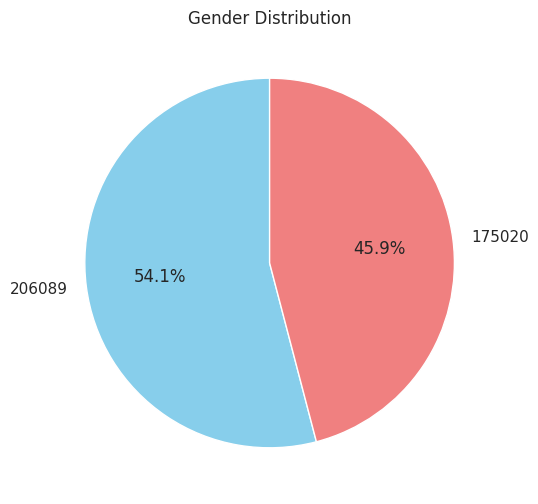

In [12]:
import seaborn as sns
# Seaborn library a Python library for data visualization

gender_counts = df['Gender'].value_counts()
#value_counts(): Counts occurrences of each gender in the Gender column.

plt.figure(figsize=(6, 6)) # Sets the figure size to 6x6 inches.
plt.pie(gender_counts, labels=gender_counts, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=90)
# labels: Gender labels, autopct='%1.1f%%': Shows percentages with 1 decimal.
# colors: Assigns colors (skyblue and lightcoral) , startangle=90: Starts the 1st segment at 90 degrees.
plt.title('Gender Distribution')    # Adds the chart title.
plt.show()

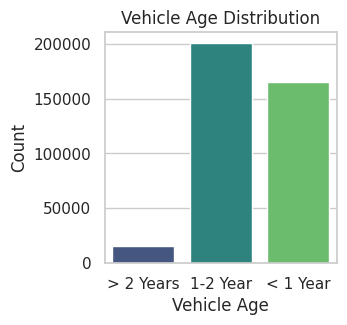

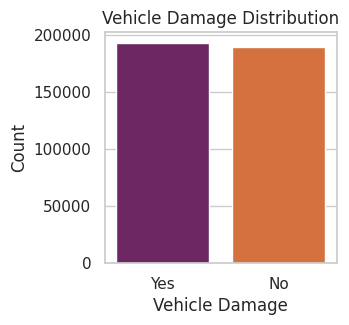

In [13]:
plt.figure(figsize=(3,3,))
sns.countplot(x='Vehicle_Age', data=df, palette='viridis')
plt.title('Vehicle Age Distribution')
plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(3,3,))
sns.countplot(x='Vehicle_Damage', data=df, palette='inferno')
plt.title('Vehicle Damage Distribution')
plt.xlabel('Vehicle Damage')
plt.ylabel('Count')
plt.show()


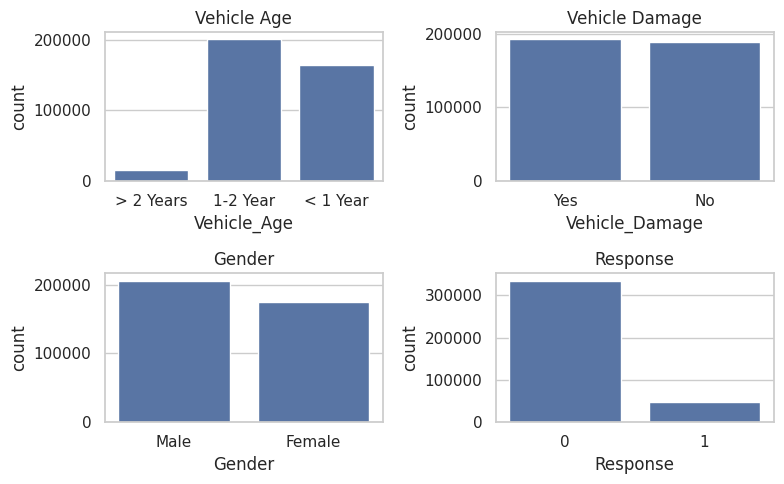

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5))

sns.countplot(x='Vehicle_Age', data=df, ax=axes[0,0])
sns.countplot(x='Vehicle_Damage', data=df, ax=axes[0,1])
sns.countplot(x='Gender', data=df, ax=axes[1,0])
sns.countplot(x='Response', data=df, ax=axes[1,1])

axes[0,0].set_title("Vehicle Age")
axes[0,1].set_title("Vehicle Damage")
axes[1,0].set_title("Gender")
axes[1,1].set_title("Response")

plt.tight_layout()
plt.show()


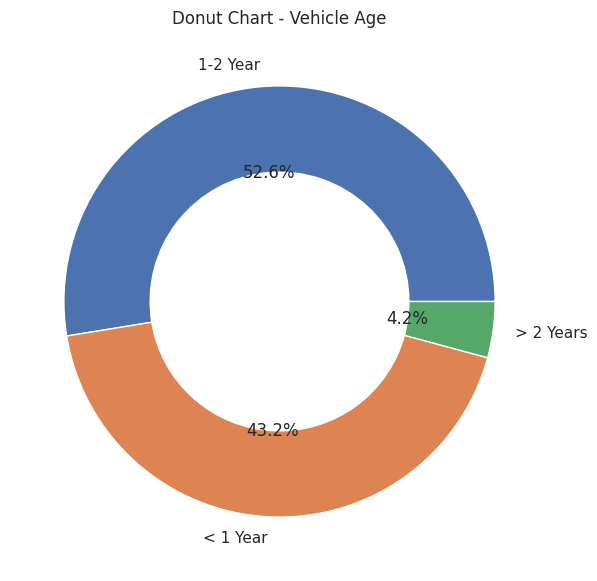

In [15]:
vehicle_age_counts = df['Vehicle_Age'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(vehicle_age_counts, labels=vehicle_age_counts.index, autopct='%1.1f%%', wedgeprops={'width':0.4})
plt.title("Donut Chart - Vehicle Age")
plt.show()


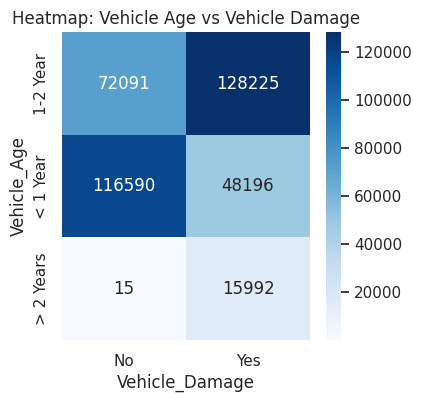

In [16]:
cross_tab = pd.crosstab(df['Vehicle_Age'], df['Vehicle_Damage'])

plt.figure(figsize=(4,4))
sns.heatmap(cross_tab, annot=True, cmap='Blues', fmt='d')
plt.title('Heatmap: Vehicle Age vs Vehicle Damage')
plt.show()


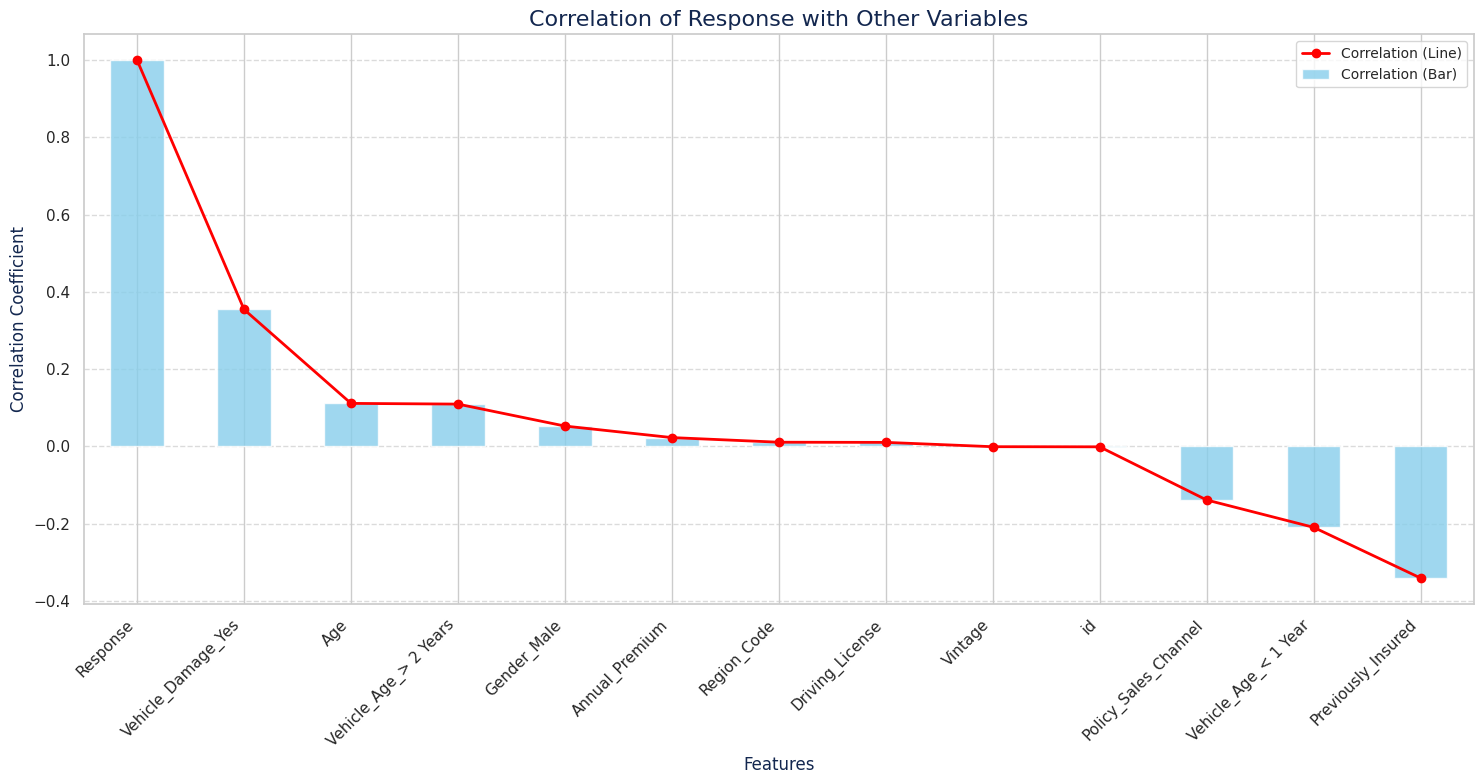

In [17]:
#  visualizes the correlations of features with the target variable (Response)

# Create a copy of df to perform encoding without altering the original df
df_encoded_for_corr = df.copy()

# Identify categorical columns
categorical_cols_for_corr = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']

# Apply one-hot encoding to categorical columns
df_encoded_for_corr = pd.get_dummies(df_encoded_for_corr, columns=categorical_cols_for_corr, drop_first=True)

# Compute correlations
correlations = df_encoded_for_corr.corr()['Response'].sort_values(ascending=False)
# df_encoded_for_corr.corr()['Response']: Computes correlations between all columns and Response.
# sort_values(ascending=False): Sorts correlations in descending order.

# Create the figure
plt.figure(figsize=(15, 8))

# Plot the bar chart
correlations.plot(kind='bar', color='skyblue', alpha=0.8, label='Correlation (Bar)')   #  Plots a bar chart of correlations with Response.

# Overlay a line plot: Adds a red line plot showing correlation values.
plt.plot(correlations.index, correlations.values, color='red', marker='o', linewidth=2, label='Correlation (Line)')

# Add title and labels
plt.title('Correlation of Response with Other Variables', fontsize=16, color='#13274F')
plt.xlabel('Features', fontsize=12, color='#13274F')
plt.ylabel('Correlation Coefficient', fontsize=12, color='#13274F')

# Add legend
plt.legend(fontsize=10)
# plt.legend(): Adds a legend to differentiate the line and bar.

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid for better  clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()         #Adjusts layout to avoid overlap.

# Show the plot
plt.show()

In [18]:
df_encoded_for_corr.value_counts()

,,,,,,,,,,,,,count
id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes,
381109,46,1,29,0,41777,26,237,0,True,False,False,False,1
1,44,1,28,0,40454,26,217,1,True,False,True,True,1
2,76,1,3,0,33536,26,183,0,True,False,False,False,1
3,47,1,28,0,38294,26,27,1,True,False,True,True,1
4,21,1,11,1,28619,152,203,0,True,True,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,32,1,6,1,28771,152,80,0,False,True,False,False,1
9,24,1,3,1,27619,152,28,0,False,True,False,False,1
8,56,1,28,0,32031,26,72,1,False,False,False,True,1


##**Distribution of Numerical Variables**

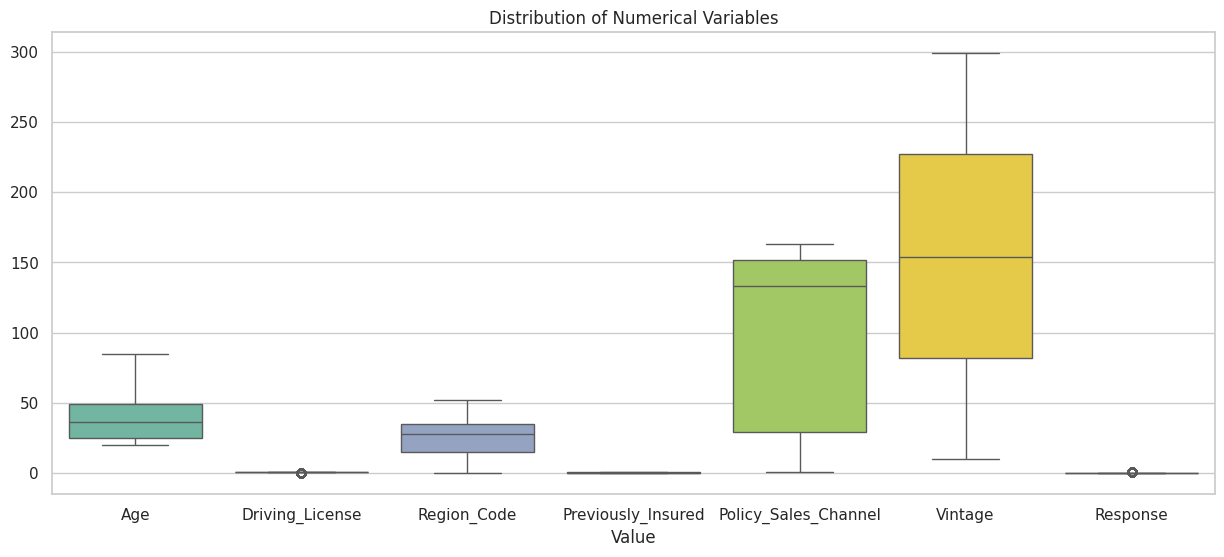

In [19]:
numerical_cols = ['Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
                  'Policy_Sales_Channel', 'Vintage', 'Response']
# numerical_cols: Selects numerical columns from the dataset: Age, Driving_License, Region_Code, Previously_Insured, Policy_Sales_Channel, Vintage, and Response.

plt.figure(figsize=(15, 6))
sns.boxplot(data=df[numerical_cols], orient='v', palette='Set2')
# sns.boxplot(): Plots the box plot for the selected numerical columns.
# orient='v': Displays the boxes horizontally.
# palette='Set2': Applies a soft color palette.

plt.title('Distribution of Numerical Variables')
plt.xlabel('Value')
plt.show()

##**Outlier Detection — Boxplots of Numerical Features**

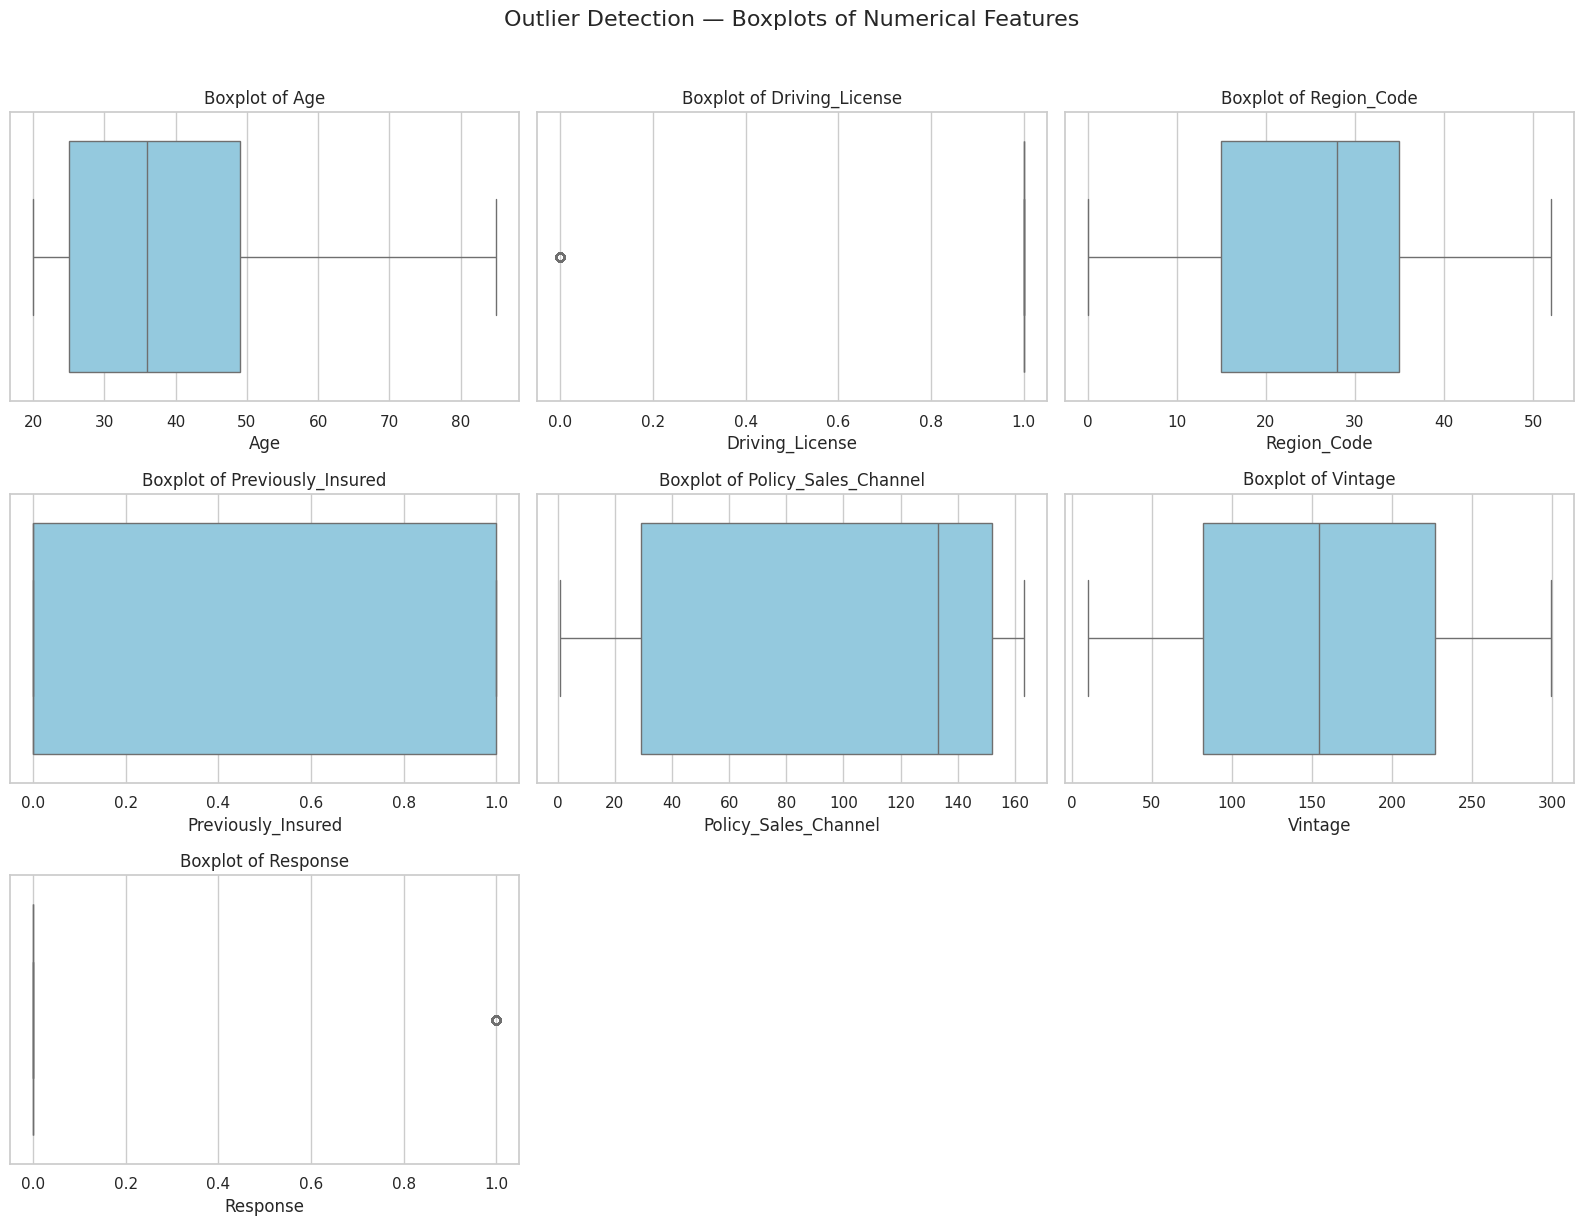

In [20]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(
        x=df[col],
        color="skyblue"
    )
    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.xlabel(col)

plt.suptitle("Outlier Detection — Boxplots of Numerical Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Outlier Detection from Boxplots:</font></h3>

<p>The boxplots of the numerical features (<b>Age</b>, <b>Region_Code</b>, <b>Annual_Premium</b>, <b>Policy_Sales_Channel</b>, and <b>Vintage</b>) provide a clear view of the distribution and presence of outliers in the dataset. Based on the visual analysis, here are the main insights:</p>

<ul>
  <li><b>Age:</b> The distribution appears fairly consistent with only a few outliers at extreme ages. These are acceptable because customers can genuinely fall in those age ranges.</li>

  <li><b>Region_Code:</b> Although treated as numerical, this feature represents encoded regions. Outliers here simply indicate regions with fewer customers, not data issues.</li>

  <li><b>Annual_Premium:</b> This feature shows a large number of extreme values (right-skewed distribution). These high premiums are considered <em>statistical outliers</em>, but they are usually valid business values. This feature may benefit from transformation (e.g., log-scaling).</li>

  <li><b>Policy_Sales_Channel:</b> Similar to Region_Code, this is an encoded categorical column. Some channels appear very frequently while others are rare, which appears as outliers but is normal.</li>

  <li><b>Vintage:</b> The values show a long range with minor outliers. These reflect how long customers have been associated with the company. Outliers here are valid and should not be removed.</li>
</ul>

<p><b>Overall Conclusion:</b> Except for <em>Annual_Premium</em>, the outliers in most numerical features represent naturally occurring values rather than errors. For modeling, it is recommended to:</p>

<ul>
  <li>Keep outliers for tree-based models (Random Forest, XGBoost).</li>
  <li>Apply transformations (like <code>log1p()</code>) to skewed features if using linear models.</li>
  <li>Avoid deleting outliers unless they are proven to be incorrect values.</li>
</ul>

</div>


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 4.1 |</span><span style='color:red'> Bivariate Analysis </span></b>

<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 4.1.1 |</span><span style='color:red'>   Bivariate Analysis -  Numerical Variables </span></b>

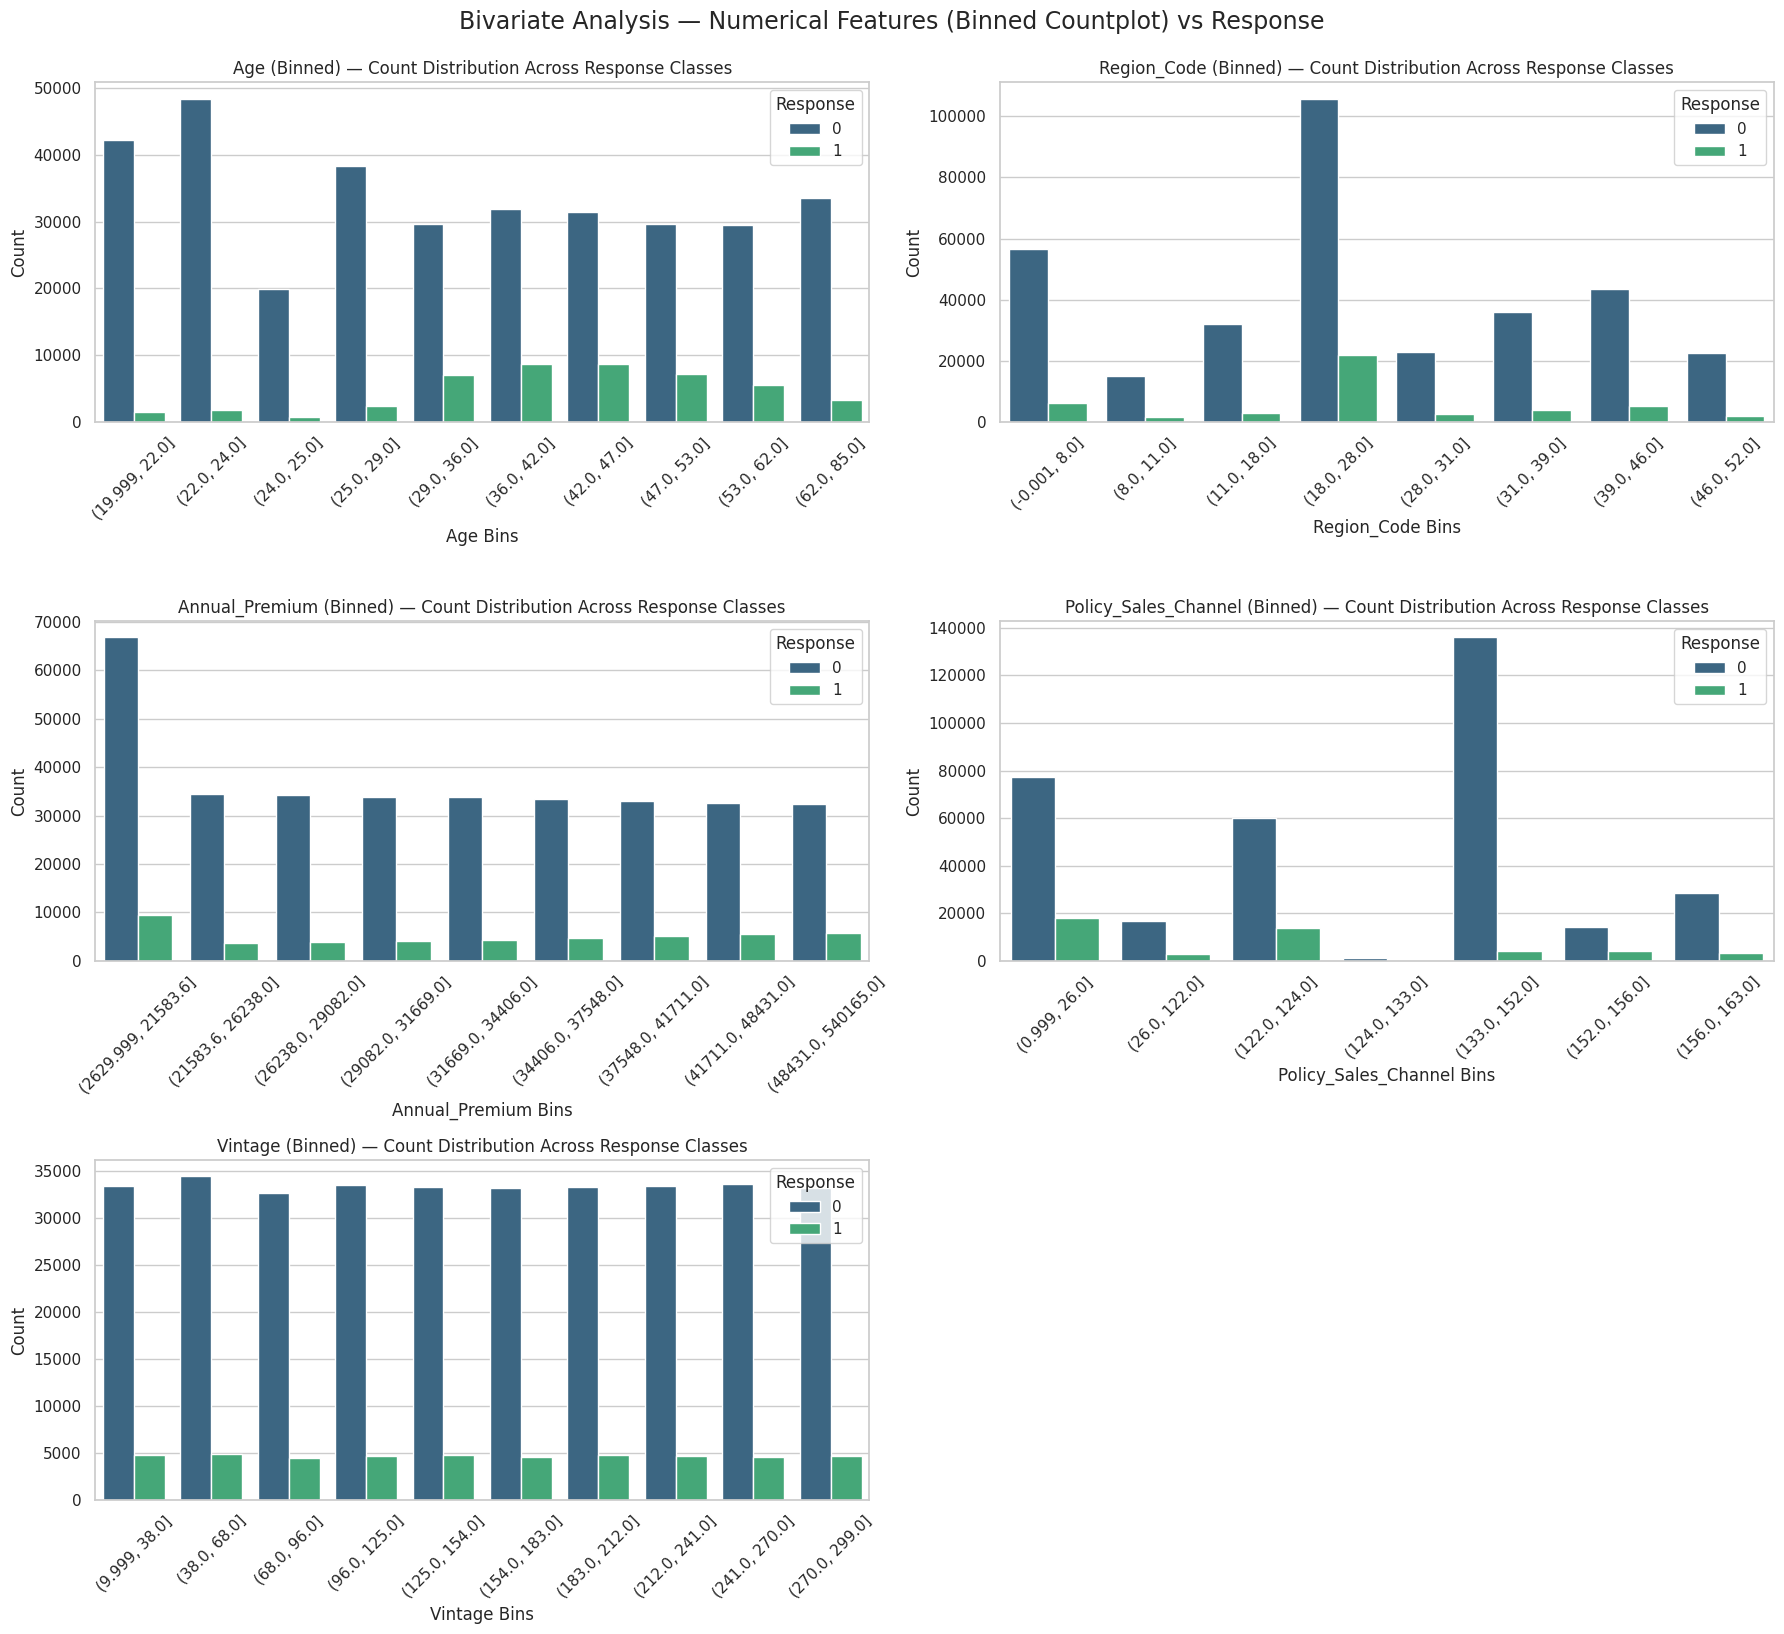

In [21]:
import pandas as pd

# Numerical columns
numerical_cols = [
    'Age',
    'Region_Code',
    'Annual_Premium',
    'Policy_Sales_Channel',
    'Vintage'
]

plt.figure(figsize=(18, 16))

for idx, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, idx)

    # Create 10 bins for continuous numeric columns
    df[col+"_binned"] = pd.qcut(df[col], q=10, duplicates='drop')

    sns.countplot(
        x=col + "_binned",
        hue='Response',
        data=df,
        palette='viridis'
    )

    plt.title(f"{col} (Binned) — Count Distribution Across Response Classes")
    plt.xlabel(f"{col} Bins")
    plt.ylabel("Count")

    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle("Bivariate Analysis — Numerical Features (Binned Countplot) vs Response", fontsize=17, y=1.02)
plt.show()


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Binned Numerical Countplots vs Response:</font></h3>

<p>The binned countplots provide a clearer and more interpretable understanding of how each numerical feature influences the likelihood of a customer responding to the insurance offer. By converting continuous variables into 10 quantile-based bins, the analysis avoids clutter and reveals meaningful trends that were not visible in the raw numerical plots.</p>

<ul>

  <li><b>Age (Binned):</b>  
      The distribution shows that customers in middle-age groups have relatively higher positive responses compared to very young or very old age groups. This suggests age plays a moderate role in influencing interest in the insurance policy.</li>

  <li><b>Region_Code (Binned):</b>  
      Since Region_Code is an encoded categorical variable, the bins represent groups of regions. Some region groups show noticeably higher response rates, indicating that geographical segmentation has an impact on customer interest.</li>

  <li><b>Annual_Premium (Binned):</b>  
      The binned premium values show that customers within lower to moderate premium ranges have a slightly higher proportion of positive responses. Extremely high premium bins show fewer responses, suggesting price sensitivity among customers.</li>

  <li><b>Policy_Sales_Channel (Binned):</b>  
      Certain channel groups (sales channels with similar frequency) show higher response counts. This indicates that some channels are more effective than others at approaching and convincing customers.</li>

  <li><b>Vintage (Binned):</b>  
      The response rate is higher among customers who have been associated with the company for a moderate amount of time. Very new and very old customers show lower engagement. This suggests customer loyalty or familiarity influences their likelihood to respond.</li>

</ul>

<p><b>Overall Conclusion:</b>  
The binned countplots reveal that numerical features do influence response behavior when grouped into meaningful ranges.  
Key insights include:</p>

<ul>
  <li>Mid-age customers respond more positively than extreme age groups.</li>
  <li>Certain region groups and sales channels have stronger engagement rates.</li>
  <li>Lower–mid premium customers respond more than high-premium customers.</li>
  <li>Customers with moderate Vintage show higher interest.</li>
</ul>

<p>This analysis helps identify which ranges within each numerical feature correlate with higher conversion likelihood, guiding targeted marketing strategies and model feature importance interpretation.</p>

</div>


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 4.2.2 |</span><span style='color:red'>   Categorical Variables Bivariate Analysis </span></b>

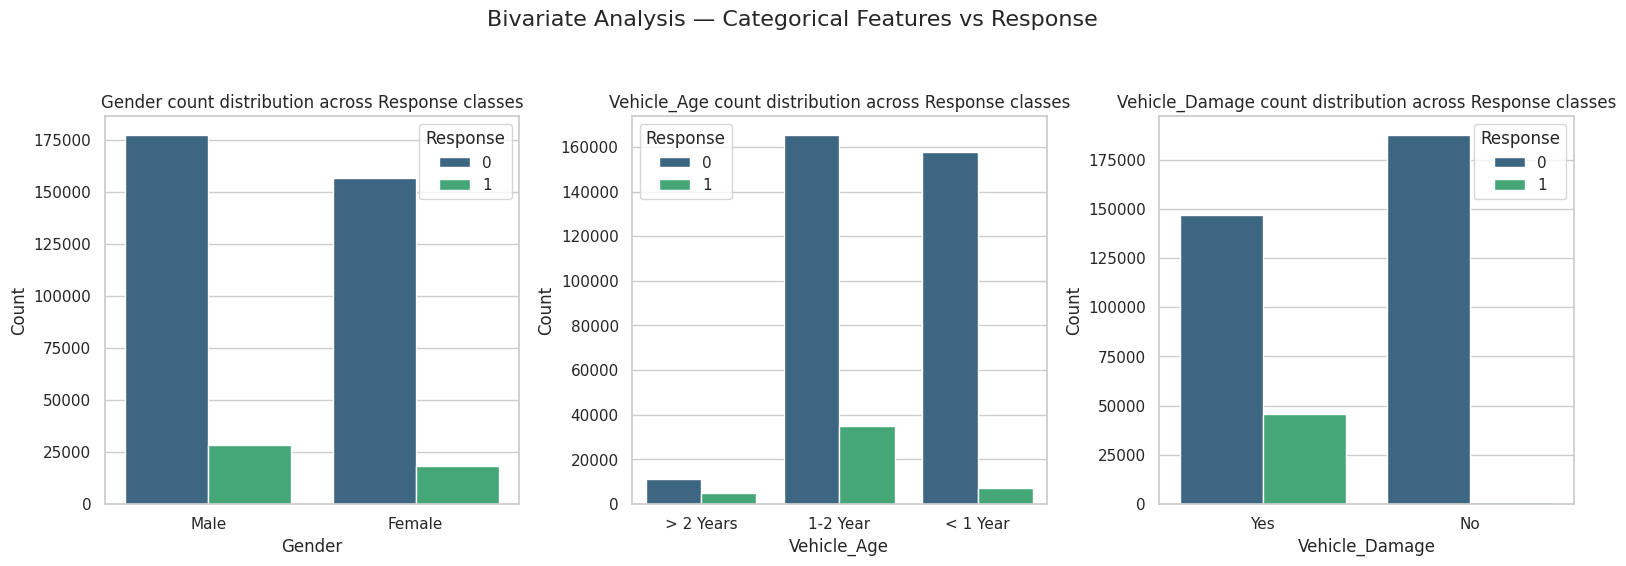

In [22]:
# Categorical columns
cat_cols = [
    'Gender',
    'Vehicle_Age',
    'Vehicle_Damage'
]

plt.figure(figsize=(16, 14))

for idx, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, idx)
    sns.countplot(
        x=col,
        hue='Response',   # shows how each category distributes across Response
        data=df,
        palette='viridis'
    )
    plt.title(f"{col} count distribution across Response classes")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.suptitle("Bivariate Analysis — Categorical Features vs Response", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


<div style="border-radius:10px; padding: 15px; background-color: #ffe1d6; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Categorical Features vs Response:</font></h3>

<p>The bivariate countplots compare each categorical feature with the target variable <b>Response</b> (0 = Not Interested, 1 = Interested). These visualizations help identify which customer groups are more likely to show interest in the insurance policy.</p>

<ul>

  <li><b>Gender:</b><br>
      Both male and female customers show a significantly higher count for <b>Response = 0</b>, indicating low overall interest.  
      However, the proportion of positive responses (<b>Response = 1</b>) is slightly higher among <b>males</b>, suggesting that male customers may be marginally more likely to respond to the insurance offer than females.</li>

  <br>

  <li><b>Vehicle_Age:</b><br>
      This feature shows a clear pattern:
      <ul>
        <li>Customers with vehicles <b>older than 2 years (&gt; 2 Years)</b> show higher positive response counts.</li>
        <li>Customers with vehicles <b>less than 1 year</b> show the lowest response rate.</li>
      </ul>
      This implies that customers with older vehicles may feel a greater need for insurance coverage.</li>

  <br>

  <li><b>Vehicle_Damage:</b><br>
      This feature has the strongest relationship with the target variable:
      <ul>
        <li>Customers whose vehicles were previously <b>damaged (Yes)</b> show a much higher proportion of positive responses.</li>
        <li>Customers whose vehicles were <b>not damaged (No)</b> rarely respond positively.</li>
      </ul>
      This is expected — customers with past vehicle damage are more likely to be interested in insurance protection.</li>

</ul>

<p><b>Overall Conclusion:</b></p>

<ul>
  <li><b>Vehicle_Damage</b> is the most impactful categorical feature — customers with past damage are far more likely to show interest.</li>
  <li><b>Vehicle_Age</b> also shows meaningful patterns — older vehicles correspond to higher response rates.</li>
  <li><b>Gender</b> has only a minor influence on the response, with males responding slightly more than females.</li>
</ul>

<p>This analysis confirms that vehicle-related features play a major role in insurance interest, and these should be given more importance during model building and feature engineering.</p>

</div>


##**Target Variable Distribution (Response = 0 vs 1)**

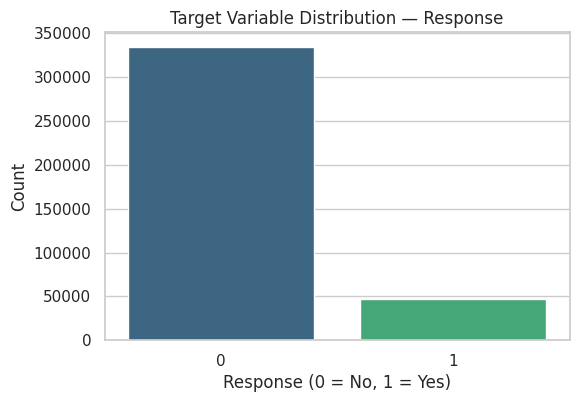

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='Response', data=df, palette='viridis')
plt.title("Target Variable Distribution — Response")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


##**Pairplot of Numerical Features vs Response:**

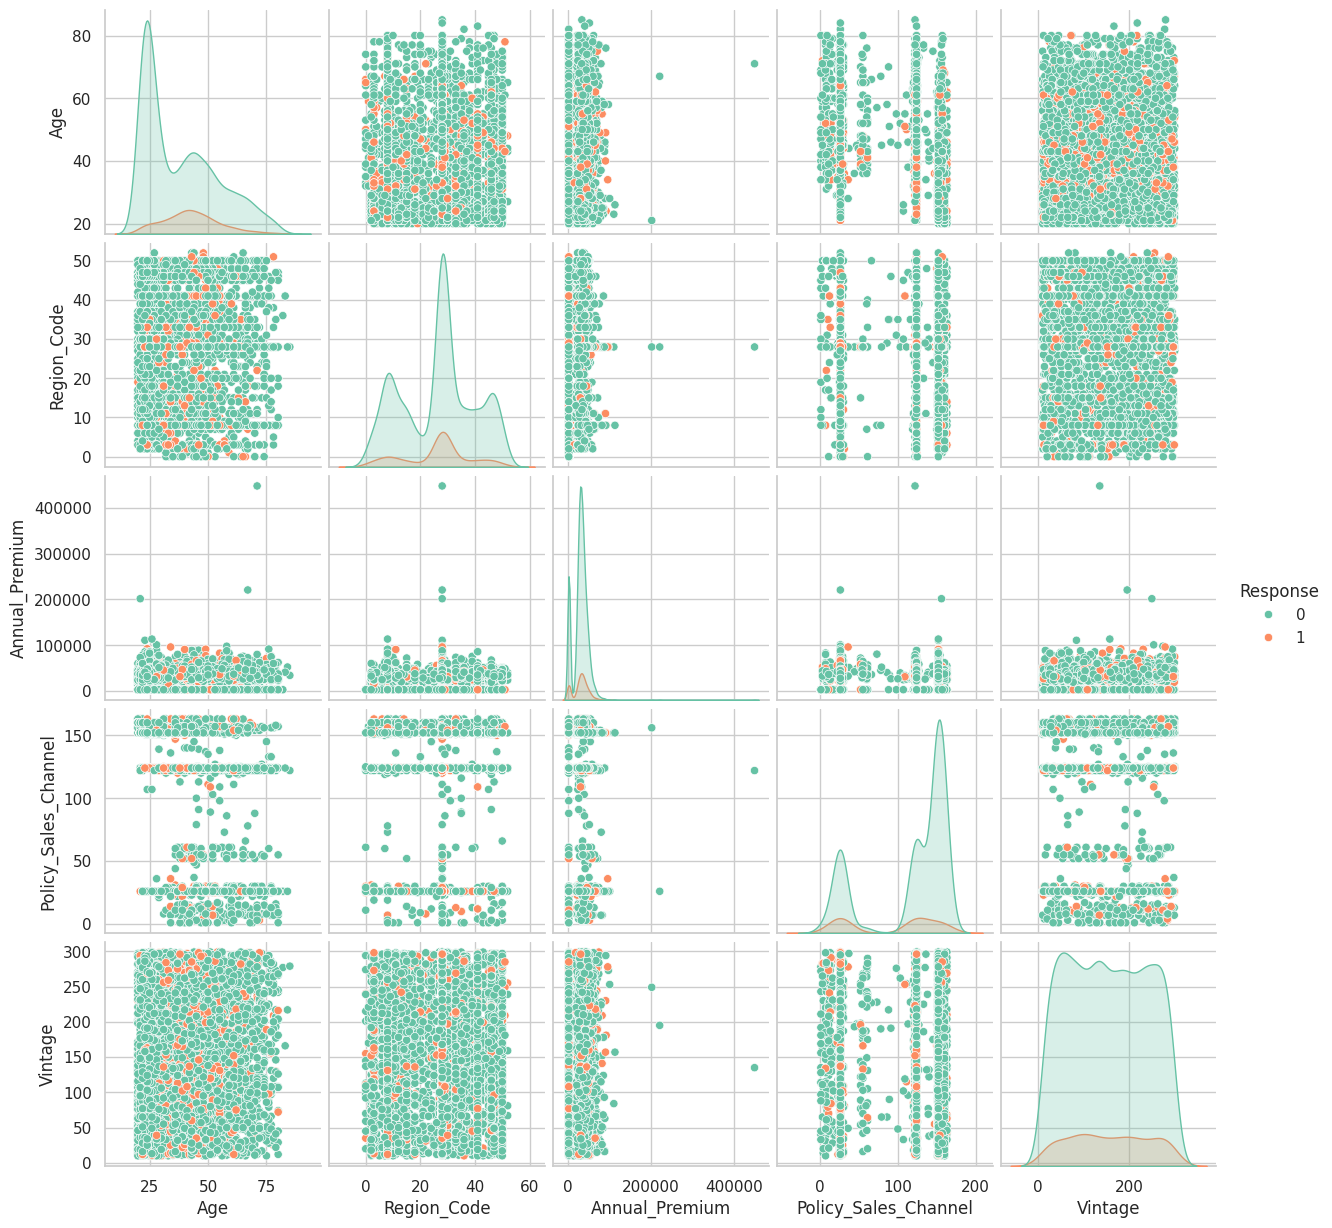

In [24]:
df_sample = df.sample(5000, random_state=42)

numeric_cols = [
    'Age',
    'Region_Code',
    'Annual_Premium',
    'Policy_Sales_Channel',
    'Vintage'
]

sns.pairplot(df_sample[numeric_cols + ['Response']], hue='Response', palette='Set2')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Pairplot of Numerical Features vs Response:</font></h3>

<p>The pairplot visualizes the relationships between all numerical features (<b>Age</b>, <b>Region_Code</b>, <b>Annual_Premium</b>, <b>Policy_Sales_Channel</b>, <b>Vintage</b>) and highlights how the two response classes (0 = Not Interested, 1 = Interested) are distributed across these combinations. Below are the key insights:</p>

<ul>

  <li><b>Age vs Other Features:</b><br>
      The points for Response = 0 and Response = 1 overlap heavily, indicating that age alone or in combination with other features does not strongly separate the classes. Age does not show a strong pattern that differentiates respondents from non-respondents.</li>

  <br>

  <li><b>Annual_Premium:</b><br>
      There is a wide spread in premium amounts, with most customers clustered in lower premium ranges.  
      <b>The minority class (Response = 1)</b> appears more concentrated in lower–moderate premium ranges, suggesting price sensitivity.</li>

  <br>

  <li><b>Vintage:</b><br>
      The distribution shows that both classes behave similarly across vintage values. Slightly more positive responses appear among customers with moderate vintage (neither too new nor too old), though the separation is not very strong.</li>

  <br>

  <li><b>Policy_Sales_Channel:</b><br>
      Channels display scattered clusters with overlapping classes, indicating that while some channels work better, no single channel clearly separates the classes in a pairplot view.</li>

  <br>

  <li><b>Region_Code:</b><br>
      As an encoded categorical variable, Region_Code forms vertical clusters. Both classes appear mixed within the clusters, showing no strong class separation.</li>

</ul>

<p><b>Overall Conclusion:</b></p>

<ul>
  <li>The pairplot shows <b>significant overlap</b> between Response 0 and Response 1 across all numerical features.</li>
  <li>No pair of numerical features clearly separates the classes visually.</li>
  <li>This confirms that the dataset is <b>complex and non-linearly separable</b>, making simple linear models less effective.</li>
  <li>Tree-based models (RandomForest, XGBoost) are more suitable because they can capture hidden patterns that are not visible in pairplots.</li>
  <li>Numerical variables alone cannot fully explain customer response; categorical features (especially <b>Vehicle_Damage</b> and <b>Vehicle_Age</b>) are more informative.</li>
</ul>

<p>This pairplot analysis helps confirm that feature interactions are subtle and strengthens the case for using advanced models with feature engineering for better prediction accuracy.</p>

</div>


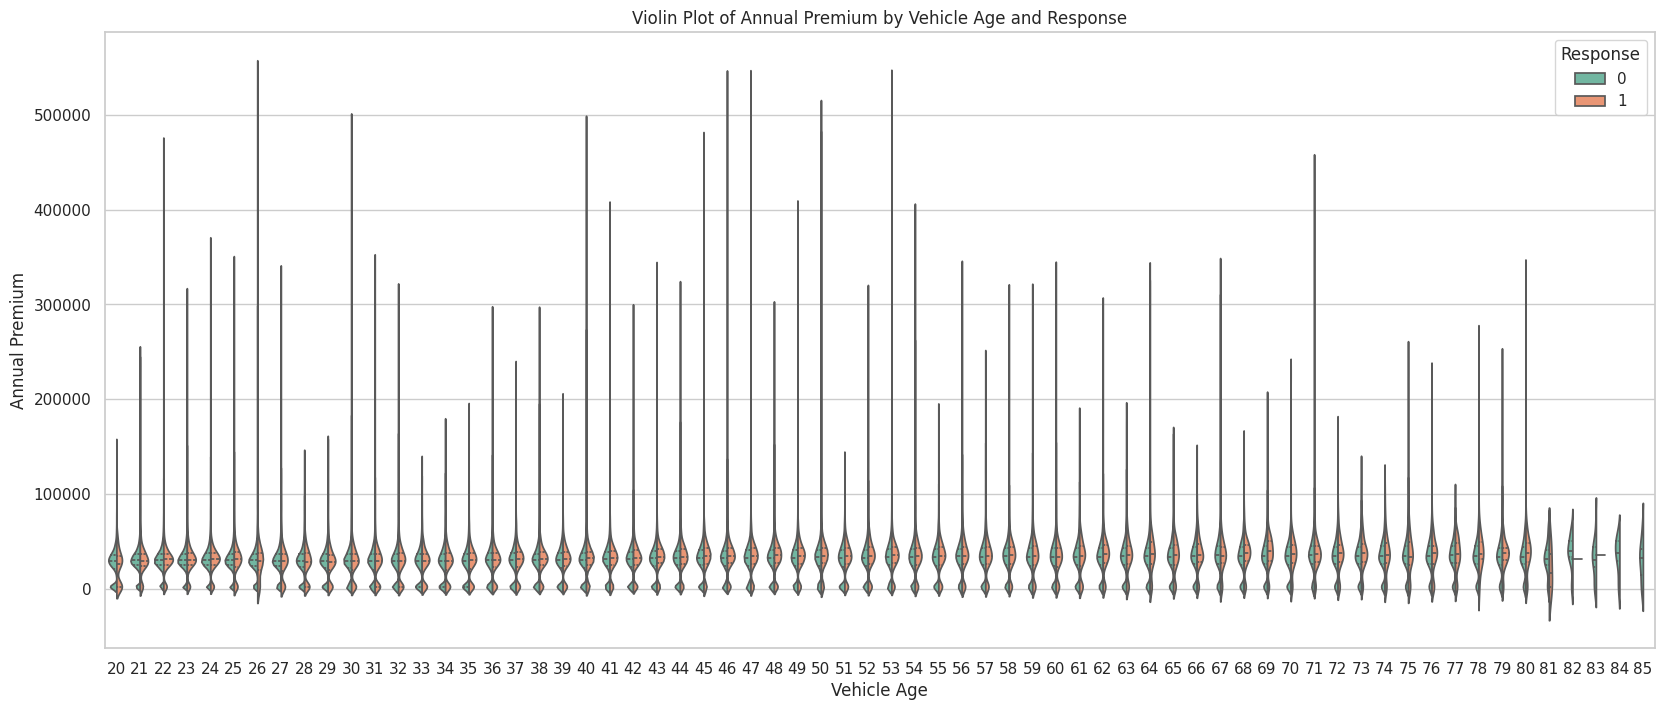

In [25]:
plt.figure(figsize=(20, 8))
sns.violinplot(x='Age', y='Annual_Premium', data=df, hue='Response', split=True, palette='Set2', inner='quartile')
# sns.violinplot(): Displays the distribution of Annual_Premium for each Age category.
# hue='Response': Adds color distinction for Response values (e.g., 0 and 1).
# split=True: Splits the violin plot for the Response categories within each Age.
# inner='quartile': Shows quartiles within the plot.

plt.title('Violin Plot of Annual Premium by Vehicle Age and Response')
plt.xlabel('Vehicle Age')
plt.ylabel('Annual Premium')
# Title and Labels: Adds context with a title, x-axis (Age), and y-axis (Annual Premium

plt.show()

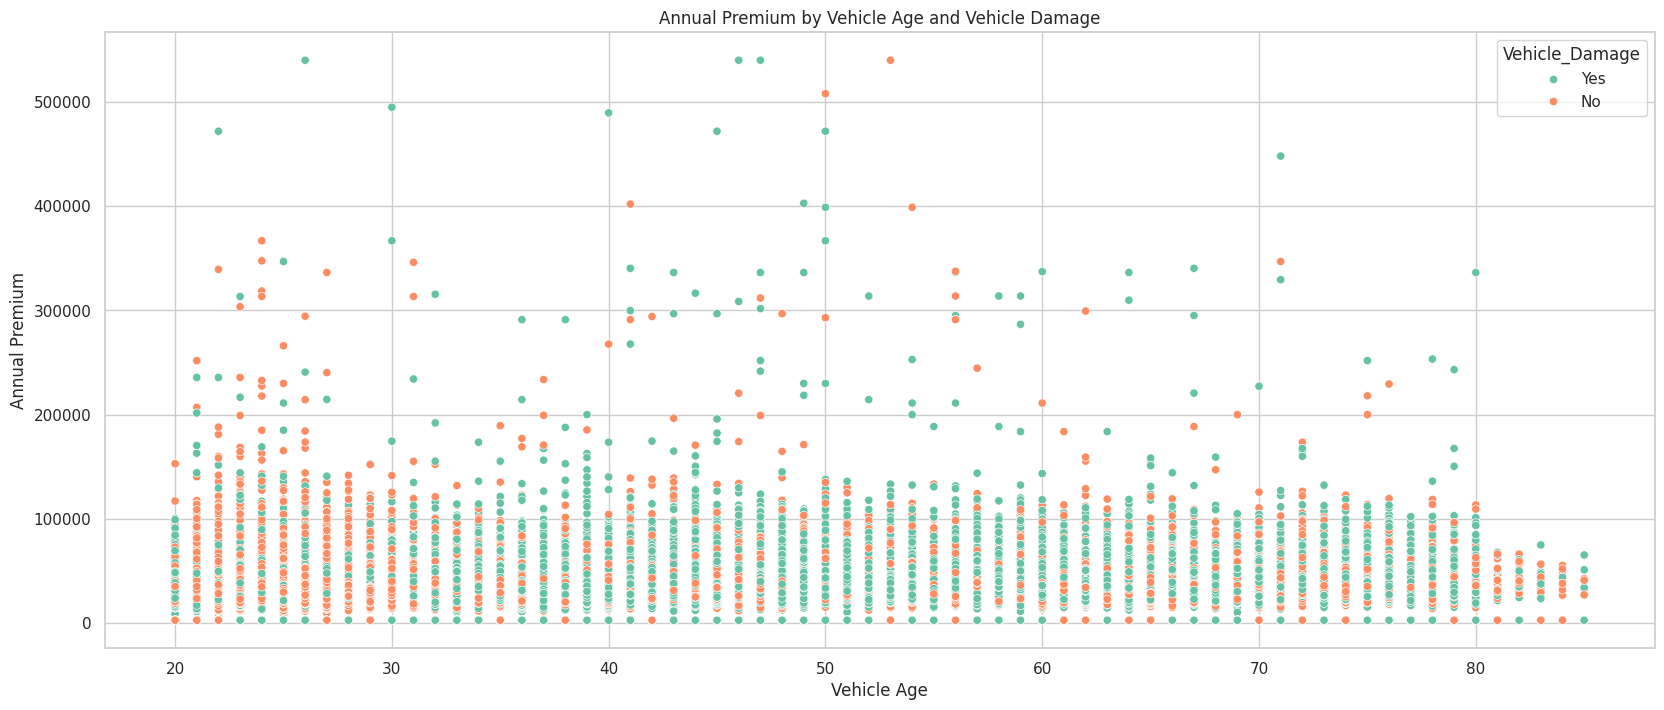

In [26]:
plt.figure(figsize=(20, 8))
sns.scatterplot(x='Age', y='Annual_Premium', hue='Vehicle_Damage', data=df, palette='Set2')
# sns.scatterplot(): Creates a scatter plot with points representing individual data samples.
# x='Age': The x-axis represents the age of the customer.
# y='Annual_Premium': The y-axis represents the annual premium amount.
# hue='Vehicle_Damage': Differentiates points by whether the vehicle has been damaged (0 for No, 1 for Yes).
#palette='Set2': Uses a color palette to represent Vehicle_Damage

plt.title('Annual Premium by Vehicle Age and Vehicle Damage')
plt.xlabel('Vehicle Age')
plt.ylabel('Annual Premium')
# plt.xlabel() and plt.ylabel(): Labels the x-axis (Vehicle Age) and y-axis (Annual Premium)

plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Scatterplot of Age vs Annual Premium (Colored by Vehicle Damage):</font></h3>

<p>This scatterplot visualizes the relationship between <b>Age</b> and <b>Annual_Premium</b>, with points colored based on whether a customer's vehicle has been previously damaged. The following insights can be observed:</p>

<ul>

  <li><b>Premium values vary widely regardless of age:</b><br>
      There is no strong pattern showing that older or younger customers consistently pay higher premiums. Premium amounts appear broadly scattered across all age groups.</li>

  <br>

  <li><b>Vehicle_Damage strongly influences distribution:</b><br>
      Customers with <b>Vehicle_Damage = Yes</b> are more heavily represented across all premium levels.  
      This indicates that customers who previously had vehicle damage are both:
      <ul>
        <li>more common in the dataset</li>
        <li>spread across the entire premium range</li>
      </ul>
      which aligns with real-world expectations (damaged vehicles lead to increased insurance interest).</li>

  <br>

  <li><b>Customers without vehicle damage show lower spread:</b><br>
      Points for <b>Vehicle_Damage = No</b> are fewer and mostly cluster around lower premiums, suggesting lower insurance interest and lower premium engagement.</li>

  <br>

  <li><b>Cluster patterns:</b><br>
      Some dense clusters appear for premium ranges around <b>20,000–40,000</b>, showing that most customers fall within this premium range irrespective of age.</li>

  <br>

  <li><b>No visible correlation:</b><br>
      Age and Annual Premium do not show a clear linear or non-linear relationship.  
      This suggests that insurance pricing in this dataset is not directly based on age alone.</li>

</ul>

<p><b>Overall Conclusion:</b></p>

<ul>
  <li>Vehicle damage status is a much stronger indicator of customer behavior than age or premium alone.</li>
  <li>Age does not significantly influence the premium value, based on this scatter plot.</li>
  <li>The presence of vehicle damage increases both the spread and frequency of customers across the premium axis, indicating higher interest from damaged-vehicle customers.</li>
  <li>This visualization supports the importance of <b>Vehicle_Damage</b> as a high-impact feature in prediction models.</li>
</ul>

<p>This plot highlights that customer behavior is more influenced by past vehicle damage than by age or annual premium alone, making Vehicle_Damage a key feature for model training.</p>

</div>


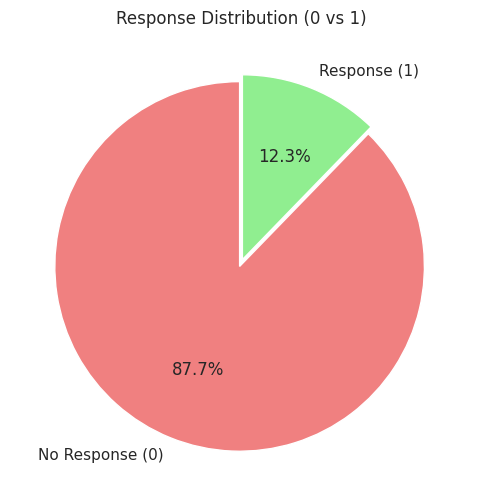

In [27]:
# Count values in Response column
response_counts = df['Response'].value_counts()

# Plot Pie Chart
plt.figure(figsize=(6,6))
plt.pie(response_counts,
        labels=['No Response (0)', 'Response (1)'],   # Labels for slices
        autopct='%1.1f%%',                           # Show percentage
        colors=['lightcoral', 'lightgreen'],          # Slice colors
        startangle=90,                                # Start angle for cleaner look
        explode=[0.02, 0.02]                          # Slight separation for emphasis
       )

plt.title("Response Distribution (0 vs 1)")
plt.show()


<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Response Distribution:</font></h3>

<p>The pie chart shows that the dataset is <b>highly imbalanced</b>. A large majority of customers fall under <b>Response = 0</b>, indicating they are not interested in purchasing insurance. Only a very small portion belong to <b>Response = 1</b>, representing interested customers.</p>

<p>This imbalance means the positive class is underrepresented, and special techniques such as <b>SMOTE, class weighting, or resampling</b> will be needed to train an effective predictive model.</p>

</div>


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 4.2 |</span><span style='color:red'>  Univariate Analysis </span></b>

<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 4.2.1 |</span><span style='color:red'> Numerical variable Univariate Analysis </span></b>

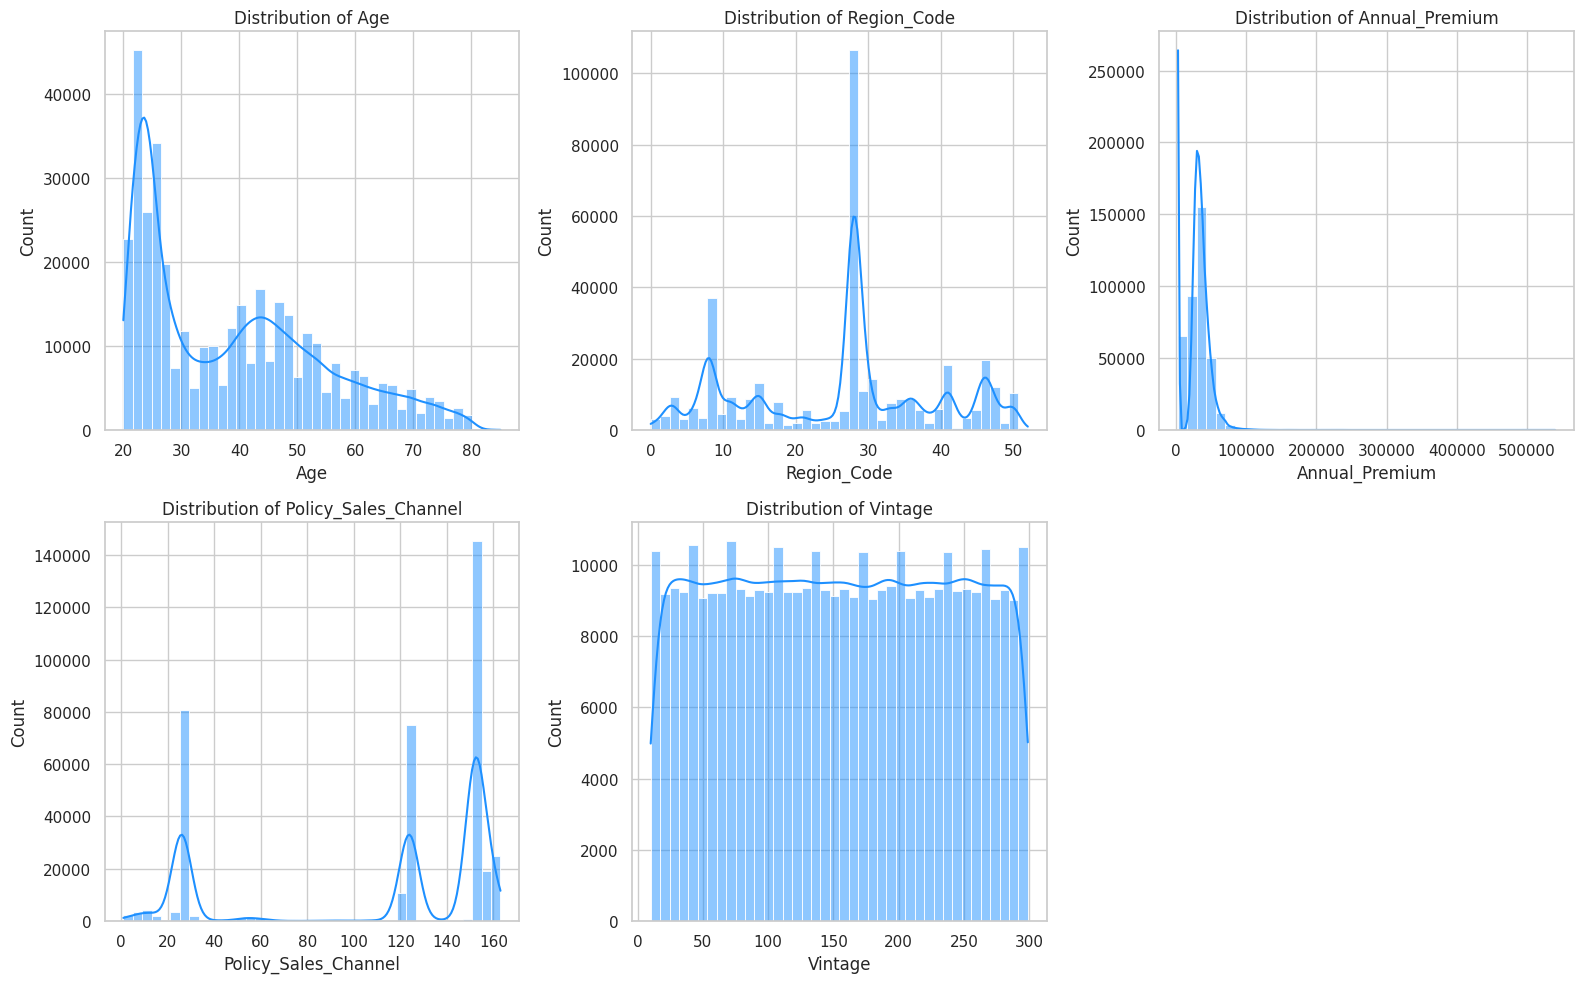

In [28]:

import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns in your insurance dataset
numeric_cols = [
    'Age',
    'Region_Code',
    'Annual_Premium',
    'Policy_Sales_Channel',
    'Vintage'
]

plt.figure(figsize=(16, 10))

# Loop through each numerical column
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)                          # 2 rows, 3 columns grid
    sns.histplot(df[col],
                 kde=True,                        # kde = smooth curve
                 bins=40,
                 color="dodgerblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Numerical Feature Distributions:</font></h3>

<p>The histograms show that the numerical features in the insurance dataset are not uniformly distributed:</p>

<ul>
  <li><b>Annual_Premium</b> is highly right-skewed, with most customers paying lower premiums and only a few paying very high amounts.</li>
  <li><b>Vintage</b> and <b>Region_Code</b> display uneven distributions, indicating that certain customer tenures and regions are more common.</li>
  <li><b>Age</b> has a moderately spread distribution, with a higher concentration of customers in mid-age groups.</li>
  <li><b>Policy_Sales_Channel</b> shows sharp peaks because some sales channels are used far more frequently than others.</li>
</ul>

<p>These skewed and uneven patterns indicate the need for transformations (like log-scaling for Annual_Premium) and proper encoding/handling during model building.</p>

</div>


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 4.2.2  |</span><span style='color:red'>  Categorical variables Univariate Analysis </span></b>

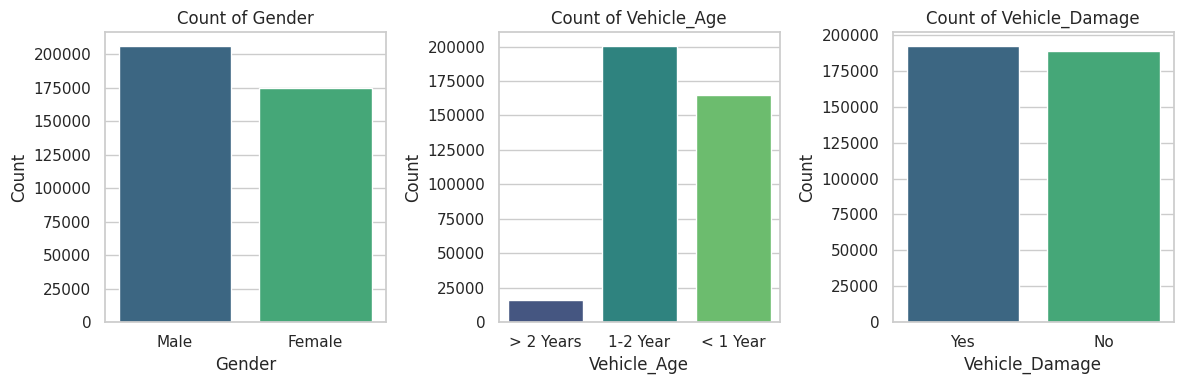

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns in your insurance dataset
cat_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']

plt.figure(figsize=(12, 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)                     # 1 row, 3 charts side by side
    sns.countplot(x=col, data=df, palette="viridis")
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Categorical Feature Counts:</font></h3>

<p>The countplots show the frequency distribution of the categorical variables in the dataset:</p>

<ul>
  <li><b>Gender:</b> The dataset contains more male customers than female customers.</li>
  <li><b>Vehicle_Age:</b> Vehicles older than 2 years form the largest group, followed by 1–2 year vehicles, while &lt;1 year vehicles are the least common.</li>
  <li><b>Vehicle_Damage:</b> A majority of customers have a history of vehicle damage, indicating this feature is highly skewed toward "Yes".</li>
</ul>

<p>These distributions show that the dataset is not uniformly balanced across categories, and vehicle-related features appear more dominant, which may strongly influence the model's predictions.</p>

</div>


#**Annual Premium by Vehicle Damage:**

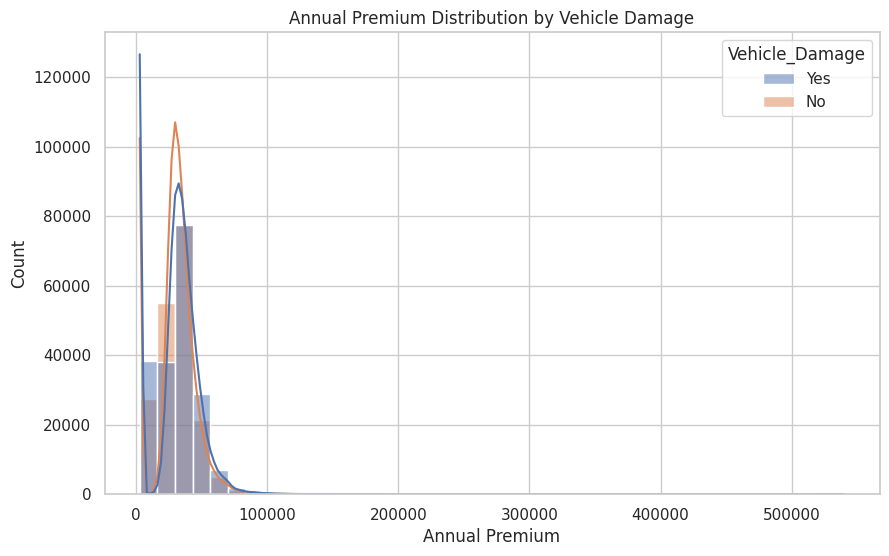

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Annual_Premium', hue='Vehicle_Damage', kde=True, bins=40, color='purple')
plt.title("Annual Premium Distribution by Vehicle Damage")
plt.xlabel("Annual Premium")
plt.ylabel("Count")
plt.show()



<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Annual Premium by Vehicle Damage:</font></h3>

<p>The histogram shows that Annual Premium is heavily right-skewed, with most customers paying lower premium amounts. Customers with <b>Vehicle_Damage = Yes</b> appear more frequently across almost all premium ranges than those with no damage.</p>

<p>This indicates that customers who previously experienced vehicle damage are more active and engaged across premium categories, making them more likely insurance prospects compared to customers without past damage.</p>

</div>


#**Handling Highly Correlated Photometric Features**



Highly correlated features can:
- Mislead models
- Increase overfitting  
Therefore, such features may be removed or combined.


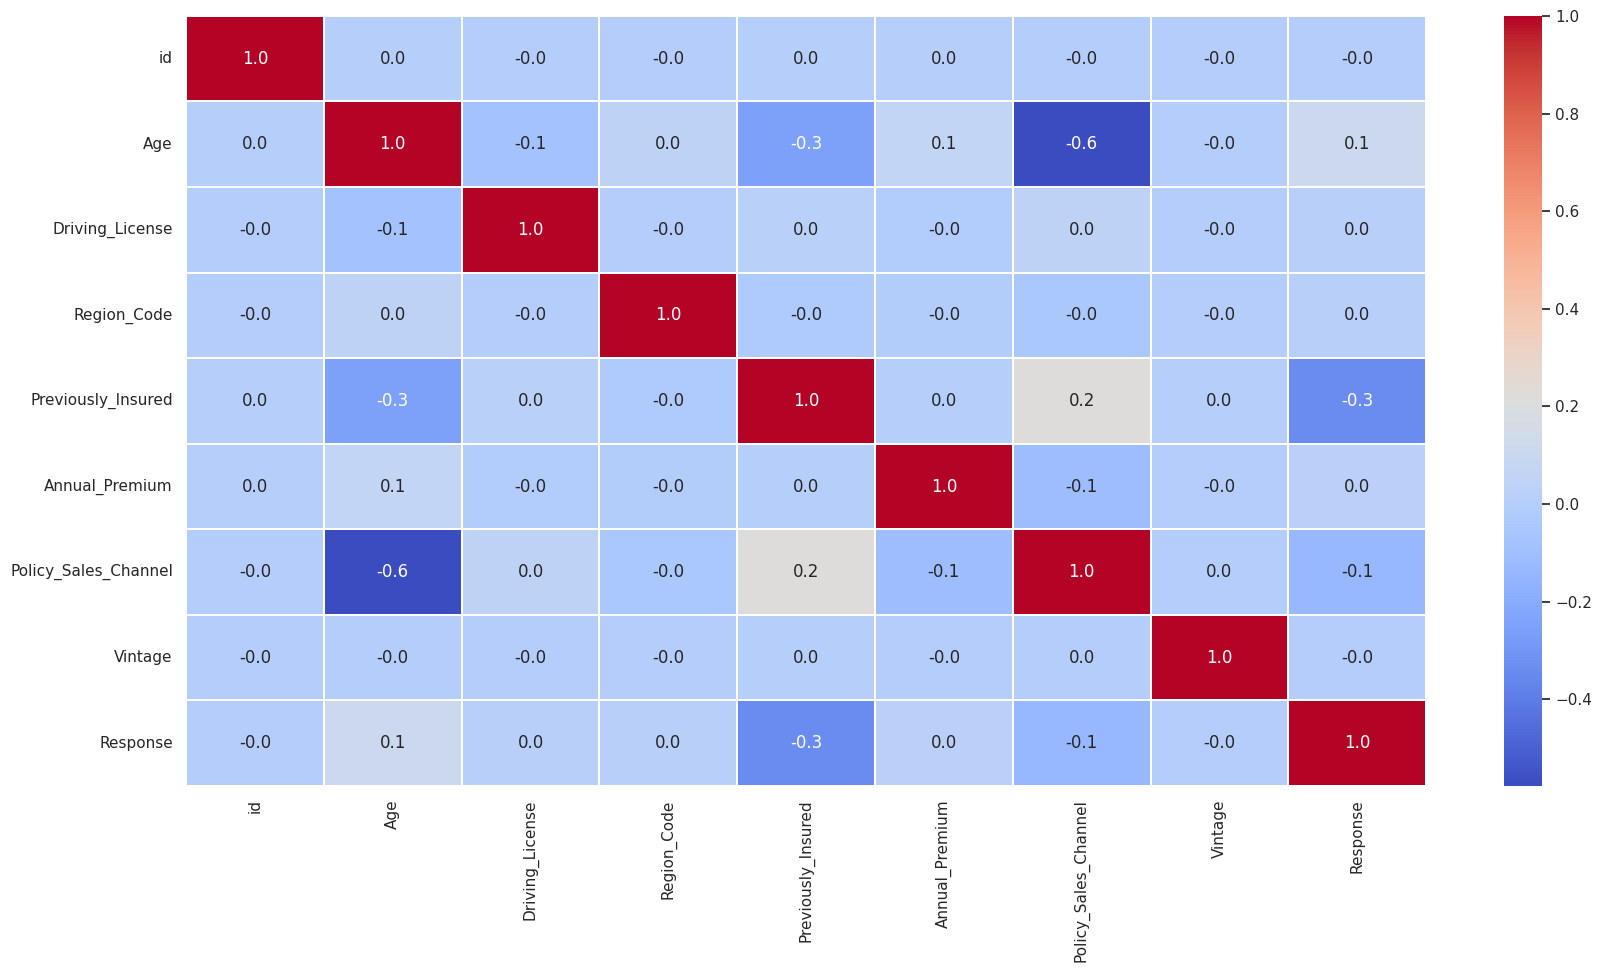

In [31]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
# LabelEncoder: Encodes the Response column into numeric values (e.g., 0 and 1

df['Response'] = encoder.fit_transform(df['Response'])
insurance_cust = pd.get_dummies(df, drop_first=True)
# pd.get_dummies(drop_first=True): Converts categorical variables into dummy variables, avoiding multicollinearity.

numeric_data = insurance_cust.select_dtypes(include=['number'])
# select_dtypes(include=['number']): Filters only numerical columns for correlation analysis.
correlation_matrix = numeric_data.corr()
# numeric_data.corr(): Computes pairwise correlation coefficients between numerical columns.

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.1)
# annot=True: Displays correlation values on the heatmap.
# cmap='coolwarm': Uses a blue-to-red color gradient.
# fmt=".1f": Formats values to one decimal point.
# linewidths=0.1: Adds thin lines between cells.


plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Correlation Heatmap:</font></h3>

<p>The correlation heatmap shows that there are no strong linear relationships between most features in the dataset. Key observations include:</p>

<ul>
  <li><b>Response</b> has weak correlations with all numerical variables, indicating that customer interest cannot be explained by a single numerical feature.</li>
  <li><b>Previously_Insured</b> shows a strong negative correlation with Response, meaning already-insured customers are highly unlikely to respond.</li>
  <li><b>Annual_Premium</b>, <b>Age</b>, <b>Vintage</b>, and <b>Region_Code</b> show very weak correlations with one another, confirming the dataset has low multicollinearity.</li>
</ul>

<p>These results suggest that the problem is non-linear, and models like Random Forest or XGBoost are more suitable than basic linear models.</p>

</div>


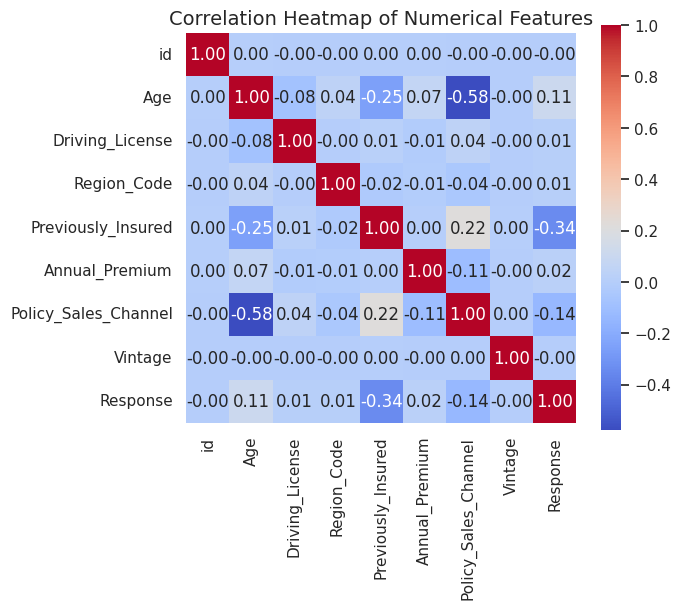

,Feature 1,Feature 2,Correlation
27,Previously_Insured,Policy_Sales_Channel,0.219381
14,Age,Response,0.111147
11,Age,Annual_Premium,0.067507
18,Driving_License,Policy_Sales_Channel,0.043731
9,Age,Region_Code,0.042574
32,Annual_Premium,Response,0.022575
16,Driving_License,Previously_Insured,0.014969
25,Region_Code,Response,0.010570
20,Driving_License,Response,0.010155
26,Previously_Insured,Annual_Premium,0.004269


In [32]:


# Use your balanced dataset
# If you're using df instead, just change df_50k_balanced to df
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Correlation matrix of only numerical features
corr = df[num_cols].corr()

plt.figure(figsize=(7, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={'shrink': 0.75}
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

# Get correlation pairs (upper triangle only, without duplicates)
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'})
        .sort_values(by='Correlation', ascending=False)
)

# Show top 15 most correlated pairs
corr_pairs.head(15)


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 5 |</span><span style='color:red'>  Data Preprocessing  </span></b>

<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 5.1 |</span><span style='color:red'>    </span></b> Missing Values Treatment




Methods include:
- Mean / Median imputation (numerical)
- Mode imputation (categorical)
- Dropping rows/columns (if missing too much)


In [33]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id                             0
Gender                         0
Age                            0
Driving_License                0
Region_Code                    0
Previously_Insured             0
Vehicle_Age                    0
Vehicle_Damage                 0
Annual_Premium                 0
Policy_Sales_Channel           0
Vintage                        0
Response                       0
Age_binned                     0
Region_Code_binned             0
Annual_Premium_binned          0
Policy_Sales_Channel_binned    0
Vintage_binned                 0
dtype: int64


<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Missing Value Check:</font></h3>

<p>The output shows that all columns have <b>zero missing values</b> in the dataset. This means the data is complete, and no imputation or missing value treatment is required. The dataset is clean and ready for further preprocessing and modeling.</p>

</div>


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 5.2 |</span><span style='color:red'>  Outlier Treatment   </span></b>

# 5.2 | Outlier Detection and Handling


Outliers are detected using:
- IQR (Interquartile Range)
- Z-score  

1.   List item
2.   List item


Handled by:
- Removing extreme points
- Capping (winsorization)

In [34]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude the 'Response' column from outlier clipping as it's the target variable
if 'Response' in numeric_cols:
    numeric_cols.remove('Response')

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

print("Outlier clipping completed for all numeric columns, excluding 'Response'.")

Outlier clipping completed for all numeric columns, excluding 'Response'.


In [35]:
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Age_binned,Region_Code_binned,Annual_Premium_binned,Policy_Sales_Channel_binned,Vintage_binned
0,1,Male,44,1,28,0,> 2 Years,Yes,40454.0,26,217,1,"(42.0, 47.0]","(18.0, 28.0]","(37548.0, 41711.0]","(0.999, 26.0]","(212.0, 241.0]"
1,2,Male,76,1,3,0,1-2 Year,No,33536.0,26,183,0,"(62.0, 85.0]","(-0.001, 8.0]","(31669.0, 34406.0]","(0.999, 26.0]","(154.0, 183.0]"
2,3,Male,47,1,28,0,> 2 Years,Yes,38294.0,26,27,1,"(42.0, 47.0]","(18.0, 28.0]","(37548.0, 41711.0]","(0.999, 26.0]","(9.999, 38.0]"
3,4,Male,21,1,11,1,< 1 Year,No,28619.0,152,203,0,"(19.999, 22.0]","(8.0, 11.0]","(26238.0, 29082.0]","(133.0, 152.0]","(183.0, 212.0]"
4,5,Female,29,1,41,1,< 1 Year,No,27496.0,152,39,0,"(25.0, 29.0]","(39.0, 46.0]","(26238.0, 29082.0]","(133.0, 152.0]","(38.0, 68.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26,1,1-2 Year,No,30170.0,26,88,0,"(62.0, 85.0]","(18.0, 28.0]","(29082.0, 31669.0]","(0.999, 26.0]","(68.0, 96.0]"
381105,381106,Male,30,1,37,1,< 1 Year,No,40016.0,152,131,0,"(29.0, 36.0]","(31.0, 39.0]","(37548.0, 41711.0]","(133.0, 152.0]","(125.0, 154.0]"
381106,381107,Male,21,1,30,1,< 1 Year,No,35118.0,160,161,0,"(19.999, 22.0]","(28.0, 31.0]","(34406.0, 37548.0]","(156.0, 163.0]","(154.0, 183.0]"
381107,381108,Female,68,1,14,0,> 2 Years,Yes,44617.0,124,74,0,"(62.0, 85.0]","(11.0, 18.0]","(41711.0, 48431.0]","(122.0, 124.0]","(68.0, 96.0]"


<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Outlier Clipping:</font></h3>

<p>The code applies IQR-based clipping to all numerical features (except the target <b>Response</b>). Values below the lower bound or above the upper bound are capped to reduce the influence of extreme outliers.</p>

<ul>
  <li>This prevents unusually large or small values from negatively affecting model performance.</li>
  <li>It preserves all rows in the dataset while controlling extreme variation.</li>
  <li>Only numerical columns are clipped, ensuring the target variable remains unchanged.</li>
</ul>

<p>Overall, this step makes the data more stable and suitable for algorithms sensitive to outliers, such as Logistic Regression and SVM.</p>

</div>


In [36]:
y=df['Response'].values
x=df.drop(columns=['Response'])

<div style="border-radius:10px; padding: 15px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Splitting Features and Target:</font></h3>

<p>This code separates the dataset into two parts:</p>

<ul>
  <li><b>y = df["Response"].values</b> → Stores the target variable (customer interest: 0 or 1).</li>
  <li><b>x = df.drop(columns=["Response"])</b> → Stores all input features used for model training.</li>
</ul>

<p>This step ensures that the model learns patterns from the features (x) and predicts the output (y) during training.</p>

</div>


In [37]:
y

array([1, 0, 1, ..., 0, 0, 0])

<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — y (Target Variable):</font></h3>

<p>The variable <b>y</b> stores the values from the <b>Response</b> column, which represents the target output for the prediction model.</p>

<ul>
  <li><b>y</b> contains only 0s and 1s — where 0 = No Response and 1 = Response.</li>
  <li>This is the label the model will learn to predict.</li>
  <li>Extracting <b>y</b> separately ensures a clear distinction between inputs (features) and the output (target).</li>
</ul>

<p>In summary, <b>y</b> is the dependent variable used for supervised learning.</p>

</div>


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 5.3 |</span><span style='color:red'>  Categorical Features Encoding & Feature Scaling    </span></b>

In [38]:
from sklearn.preprocessing import MinMaxScaler

# Identify categorical columns
categorical_cols = x.select_dtypes(include='object').columns

# Drop binned columns before one-hot encoding, as they are not suitable for scaling
x = x.drop(columns=[col for col in x.columns if col.endswith('_binned')], errors='ignore')

# Apply one-hot encoding to categorical columns
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

features = x.columns.values

scaler = MinMaxScaler(feature_range=(0,1))

scaler.fit(x)

x = pd.DataFrame(scaler.transform(x))

x.columns = features

x.head()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,0.000000,0.369231,0.0,0.538462,0.0,0.638245,0.154321,0.716263,1.0,0.0,1.0,1.0
1,0.000003,0.861538,0.0,0.057692,0.0,0.521510,0.154321,0.598616,1.0,0.0,0.0,0.0
2,0.000005,0.415385,0.0,0.538462,0.0,0.601797,0.154321,0.058824,1.0,0.0,1.0,1.0
3,0.000008,0.015385,0.0,0.211538,1.0,0.438540,0.932099,0.667820,1.0,1.0,0.0,0.0
4,0.000010,0.138462,0.0,0.788462,1.0,0.419591,0.932099,0.100346,0.0,1.0,0.0,0.0


<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Final Preprocessing (Encoding + Scaling + Cleanup):</font></h3>

<p>This code performs the final preprocessing steps required to prepare the dataset for model training:</p>

<ul>
  <li><b>Removing binned columns:</b>  
      Any column ending with <code>_binned</code> is dropped because binned categories are not meaningful for scaling and can distort the model.</li>

  <li><b>One-hot encoding categorical variables:</b>  
      All object-type categorical columns are converted into dummy variables using <code>pd.get_dummies()</code>, ensuring the dataset is fully numeric.</li>

  <li><b>MinMax Scaling:</b>  
      All input features are scaled between <b>0 and 1</b>, making training more stable and preventing large-valued features from dominating.</li>

  <li><b>Feature names preserved:</b>  
      The scaled DataFrame is reconstructed with original feature names for clarity and compatibility.</li>
</ul>

<p>Overall, this step ensures the dataset is fully numeric, clean, and consistently scaled—ready for efficient model training.</p>

</div>


In [39]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101)
#x: Features (input data) , y: Target variable (output).
# test_size=0.2: 20% of the data is used for testing, and 80% for training.
# random_state=101: Ensures reproducibility by fixing the random seed.

x_train.shape,x_test.shape
# x_train.shape, x_test.shape: Displays the shape (number of rows and columns) of the training and testing feature sets

((304887, 12), (76222, 12))

<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Train-Test Split:</font></h3>

<p>The dataset is split into training and testing sets using a 80:20 ratio. This ensures that:</p>

<ul>
  <li><b>80%</b> of the data is used to train the model.</li>
  <li><b>20%</b> of the data is kept aside to evaluate how well the model performs on unseen data.</li>
  <li><b>random_state=101</b> ensures the split is reproducible every time the code is run.</li>
</ul>

<p>The shapes printed confirm that the data has been correctly divided into training and testing feature sets.</p>

</div>


In [40]:
from imblearn.over_sampling import SMOTE
# SMOTE (Synthetic Minority Over-sampling Technique)

from collections import Counter
# Imports the Counter class from the collections module.Counter helps count the frequency of different classes in your dataset

<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — SMOTE & Counter Imports:</font></h3>

<p>The code imports two important tools for handling class imbalance:</p>

<ul>
  <li><b>SMOTE:</b>  
      Used to oversample the minority class by creating synthetic samples, helping balance the dataset before model training.</li>

  <li><b>Counter:</b>  
      Helps count how many samples belong to each class, making it easier to see the level of imbalance before and after applying SMOTE.</li>
</ul>

<p>These tools are essential because the dataset has a very small number of customers with <b>Response = 1</b>, making oversampling necessary for a fair and effective model.</p>

</div>


##Predictive modeling - ML Algorithms

In [41]:
x = df.drop(['Response'], axis = 1)
# axis=1: Specifies that a column (not a row) is being dropped.

y = df.loc[:,'Response'].values
# Extracts the Response column as the target variable.
# .values: Converts the column into a NumPy array for easier manipulation during model training.

In [42]:
x.dropna(inplace=True)
# x.dropna(inplace=True) removes rows with missing values from x directly.

In [43]:
# Reload df from the CSV to ensure 'Response' column is intact
df = pd.read_csv('/content/drive/MyDrive/Insurance_Response.csv')

# Verify the response column after fresh reload
print("Response value counts after fresh reload:")
print(df['Response'].value_counts())

# Extract x and y
y = df["Response"].values
x = df.drop(columns=["Response"])

# Identify categorical columns for one-hot encoding
categorical_cols = x.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

# Now apply SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

sm = SMOTE(random_state=42)
print('Original dataset shape %s' % Counter(y))

x_res, y_res = sm.fit_resample(x, y)

print('Resampled dataset shape %s' % Counter(y_res))

Response value counts after fresh reload:
Response
0    334399
1     46710
Name: count, dtype: int64
Original dataset shape Counter({np.int64(0): 334399, np.int64(1): 46710})
Resampled dataset shape Counter({np.int64(1): 334399, np.int64(0): 334399})


In [44]:
x

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,44,1,28,0,40454,26,217,True,False,True,True
1,2,76,1,3,0,33536,26,183,True,False,False,False
2,3,47,1,28,0,38294,26,27,True,False,True,True
3,4,21,1,11,1,28619,152,203,True,True,False,False
4,5,29,1,41,1,27496,152,39,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,74,1,26,1,30170,26,88,True,False,False,False
381105,381106,30,1,37,1,40016,152,131,True,True,False,False
381106,381107,21,1,30,1,35118,160,161,True,True,False,False
381107,381108,68,1,14,0,44617,124,74,False,False,True,True


In [45]:
df.Response.value_counts()


,count
Response,
0,334399
1,46710


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 6 | Logistic Regression Model Building </span><span style='color:red'>      </span></b>

In [46]:
from sklearn.linear_model import LogisticRegression
#  imports the Logistic Regression model from scikit-learn.

<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Logistic Regression Import:</font></h3>

<p>This line imports the <b>LogisticRegression</b> model from scikit-learn, which is used for binary classification.</p>

<ul>
  <li>It helps predict whether a customer will respond (1) or not (0).</li>
  <li>It is a simple, fast, and interpretable machine-learning algorithm.</li>
  <li>Commonly used as a baseline model to compare performance with more advanced models.</li>
</ul>

<p>This import allows us to build and train a logistic regression classifier for the insurance response prediction task.</p>

</div>


In [47]:
x_train,x_test,y_train,y_test=train_test_split(x_res,y_res,test_size=0.2,random_state=101, stratify=y_res)
#x: Features (input data) , y: Target variable (output).
# test_size=0.2: 20% of the data is used for testing, and 80% for training.
# random_state=101: Ensures reproducibility of the split.
# stratify=y_res: Ensures that the train and test sets have roughly the same proportion of target labels as the complete set.

x_train.shape,x_test.shape
# Displays the shape (rows and columns) of the training and testing feature sets.

((535038, 12), (133760, 12))

In [48]:
x_res.shape,y_res.shape
# x_res.shape and y_res.shape display the shape of the resampled dataset after applying SMOTE
#x_res.shape=Shows the number of rows (samples) and columns (features) in the resampled feature set. y_res.shape=Shows the number of rows (samples) in the resampled target set

((668798, 12), (668798,))

In [49]:
# Trains a Logistic Regression model:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
# Fits the model to the training data.

LogisticRegression(max_iter=1000)

In [50]:
from sklearn import metrics


In [51]:
prediction_test=model.predict(x_test)
# Predicts the target values for the test set (x_test).

print(metrics.accuracy_score(y_test,prediction_test))
# metrics.accuracy_score(y_test, prediction_test)=Compares the true values (y_test) with the predicted values (prediction_test) and calculates the accuracy of the model
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, prediction_test))

0.8204246411483254
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.73      0.80     66880
           1       0.77      0.91      0.84     66880

    accuracy                           0.82    133760
   macro avg       0.83      0.82      0.82    133760
weighted avg       0.83      0.82      0.82    133760



<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Logistic Regression Predictions & Evaluation:</font></h3>

<p>This code evaluates the Logistic Regression model on the test data:</p>

<ul>
  <li><b>prediction_test = model.predict(x_test)</b>  
      Generates predicted class labels (0 or 1) for unseen test data.</li>

  <li><b>accuracy_score</b>  
      Measures how many predictions were correct, providing an overall accuracy value.</li>

  <li><b>classification_report</b>  
      Shows detailed metrics such as Precision, Recall, and F1-score for both classes, which is important for imbalanced datasets.</li>
</ul>

<p>These results help determine how well the model performs and whether it correctly identifies customers likely to respond to the insurance offer.</p>

</div>


Axes(0.125,0.11;0.775x0.77)


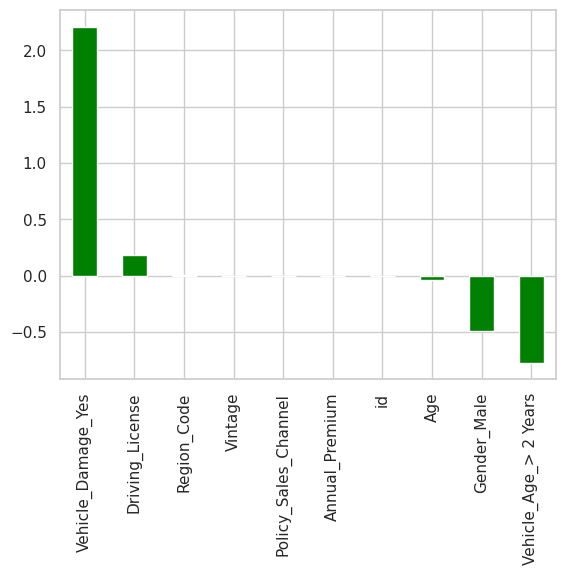

In [52]:
# To get weight of all variables
weights=pd.Series(model.coef_[0],index=x.columns.values)
# model.coef_[0]: Gets the feature weights.

print(weights.sort_values(ascending=False)[:10].plot(kind="bar",color="green"))
# weights.sort_values(ascending=False)[:10].plot(kind="bar", color="green"): Plots the top 10 coefficients as a bar chart.

Axes(0.125,0.11;0.775x0.77)


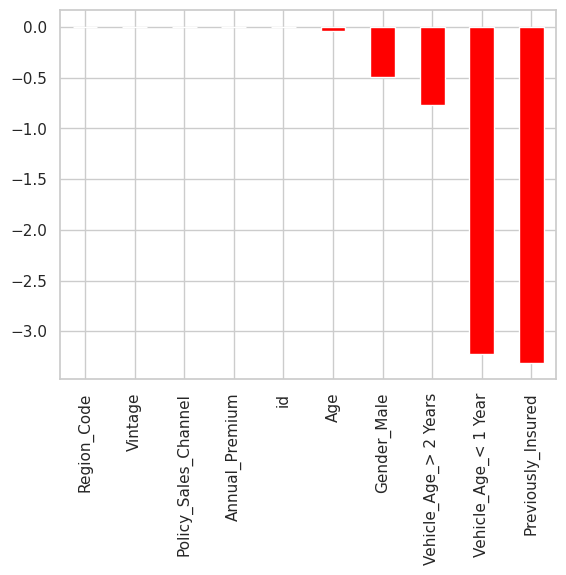

In [53]:
print(weights.sort_values(ascending = False)[-10:].plot(kind='bar', color = 'red'))
# weights.sort_values(ascending=False)[-10:]: Selects the bottom 10 features.
# .plot(kind='bar', color='red'): Plots them as a red bar chart.

plt.show()

<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 7 | Decision Tree Model Training & Accuracy</span><span style='color:red'>     

</span></b>

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Split the dataset into 80% training and 20% testing.
x_train, x_test, y_train, y_test = train_test_split(
    x_res, y_res, test_size=0.2, random_state=101
)

# Initialize the Decision Tree Classifier
model_dt = DecisionTreeClassifier(
    random_state=101,       # Ensures reproducibility
    max_depth=None,         # Tree grows fully (you can tune it)
    min_samples_leaf=1      # Minimum samples required in a leaf
)

# Train the Decision Tree model
model_dt.fit(x_train, y_train)

# Make predictions on the test data
prediction_test = model_dt.predict(x_test)

# Print accuracy score
print(metrics.accuracy_score(y_test, prediction_test))
# metrics.accuracy_score(y_test, prediction_test): Calculates and prints the accuracy score of the model.


0.8491925837320574


<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Decision Tree Model Training & Accuracy:</font></h3>

<p>This code trains a Decision Tree Classifier and evaluates its performance on the test data:</p>

<ul>
  <li>The dataset is split into <b>80% training</b> and <b>20% testing</b> to check model performance on unseen data.</li>

  <li>A <b>DecisionTreeClassifier</b> is initialized with a fixed random state for reproducibility.  
      The tree grows fully because no max depth limit is set.</li>

  <li>The model is trained on <b>x_train</b> and <b>y_train</b>.</li>

  <li><b>prediction_test</b> contains the predicted responses for the test set.</li>

  <li><b>accuracy_score</b> shows how many predictions the model got correct.</li>
</ul>

<p>Overall, this step provides the baseline accuracy of the Decision Tree model before applying any hyperparameter tuning.</p>

</div>


In [55]:
# Print Confusion Matrix
print(confusion_matrix(y_test, prediction_test))
# y_test: The true target values.
# prediction_test: The predicted values from the Decision Tree model.

[[56493 10607]
 [ 9565 57095]]


In [56]:
print(confusion_matrix(y_test, prediction_test))
# Print Classification Report
# y_test_rf: The true target values.
# prediction_test_rf: The predicted values from the model.
print("Classification Report for Decision Tree:")
print(classification_report(y_test, prediction_test))

[[56493 10607]
 [ 9565 57095]]
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     67100
           1       0.84      0.86      0.85     66660

    accuracy                           0.85    133760
   macro avg       0.85      0.85      0.85    133760
weighted avg       0.85      0.85      0.85    133760



<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Decision Tree Evaluation:</font></h3>

<p>This code evaluates the Decision Tree model using two key metrics:</p>

<ul>
  <li><b>Confusion Matrix:</b>  
      Shows how many predictions were correct or incorrect for each class (0 and 1).  
      It helps identify whether the model is misclassifying the minority class (Response = 1).</li>

  <li><b>Classification Report:</b>  
      Provides detailed performance metrics such as <b>Precision</b>, <b>Recall</b>, and <b>F1-score</b> for both classes.  
      These metrics are especially important because the dataset is imbalanced.</li>
</ul>

<p>Overall, this evaluation helps understand how well the Decision Tree predicts both responding and non-responding customers.</p>

</div>


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 8 | </span><span style='color:red'>Random Forest Model Training & Accuracy </span></b>

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, random_state=101)
# train_test_split(x, y, test_size=0.2, random_state=101):Splits the dataset into 80% training and 20% testing.

model_rf = RandomForestClassifier(n_estimators=1000, oob_score=True, n_jobs=-1, random_state=101, max_leaf_nodes=30)
# Initializes a Random Forest Classifier with 1000 trees, out-of-bag scoring (oob_score=True), parallel computation (n_jobs=-1),and a maximum of 30 leaf nodes per tree.

model_rf.fit(x_train, y_train)
# Trains the Random Forest model on the training dat


# Make predictions

prediction_test = model_rf.predict(x_test)
# prediction_test = model_rf.predict(x_test):Predicts the target values for the test set.

print(metrics.accuracy_score(y_test, prediction_test))
# metrics.accuracy_score(y_test, prediction_test):Calculates and prints the accuracy score of the model.

0.8452751196172249


<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Random Forest Model Training & Accuracy:</font></h3>

<p>This code trains a Random Forest classifier and evaluates its accuracy:</p>

<ul>
  <li>The dataset is split into <b>80% training</b> and <b>20% testing</b> to measure generalization performance.</li>

  <li>A <b>RandomForestClassifier</b> with 1000 trees is created to improve prediction stability and reduce overfitting.</li>

  <li><b>oob_score=True</b> provides an additional internal validation score using unused samples.</li>

  <li>The model is trained on <b>x_train</b> and <b>y_train</b>.</li>

  <li><b>prediction_test</b> contains the model's predictions for unseen test data.</li>

  <li><b>accuracy_score</b> calculates how many predictions were correct out of all test samples.</li>
</ul>

<p>Overall, this step gives the baseline accuracy of the Random Forest model, which is generally more robust than a single decision tree.</p>

</div>


In [58]:
print(confusion_matrix(y_test,prediction_test))
# y_test: The true target values.
# preds: The predicted values from the model.

[[50744 16356]
 [ 4340 62320]]


In [59]:
print(confusion_matrix(y_test, prediction_test))
# y_test_rf: The true target values.
# prediction_test_rf: The predicted values from the model.
print("Classification Report for Random Forest:")
print(classification_report(y_test, prediction_test))

[[50744 16356]
 [ 4340 62320]]
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.76      0.83     67100
           1       0.79      0.93      0.86     66660

    accuracy                           0.85    133760
   macro avg       0.86      0.85      0.84    133760
weighted avg       0.86      0.85      0.84    133760



<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Random Forest Evaluation:</font></h3>

<p>This code evaluates the Random Forest model using two important metrics:</p>

<ul>
  <li><b>Confusion Matrix:</b>  
      Shows how many predictions were correct and incorrect for each class (0 = No Response, 1 = Response).  
      It helps identify whether the model is correctly detecting the minority class (Response = 1).</li>

  <li><b>Classification Report:</b>  
      Provides Precision, Recall, and F1-score for both classes.  
      These metrics reveal how well the model handles the imbalanced dataset and whether it can effectively identify customers who are likely to respond.</li>
</ul>

<p>Overall, this evaluation summarizes the Random Forest model’s ability to correctly classify both responding and non-responding customers.</p>

</div>


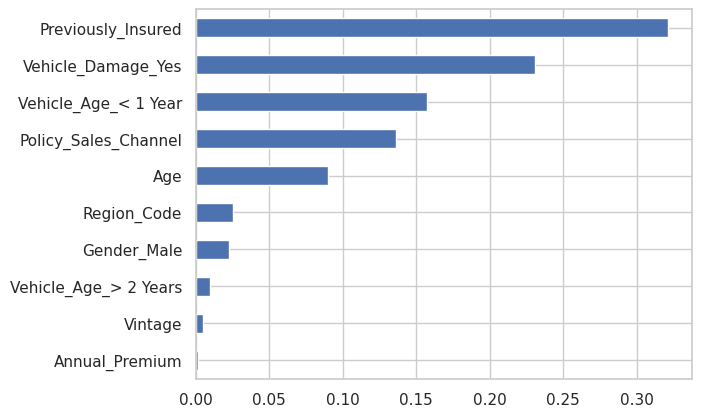

In [60]:
importances = model_rf.feature_importances_
# Retrieves the feature importance values (how much each feature contributes to the model).

weights = pd.Series(importances,index=x.columns.values)
# Converts the importances into a pandas Series with feature names as indices.

weights.sort_values()[-10:].plot(kind = 'barh')
# Sorts the importances in ascending order and selects the bottom 10 features.Plots the bottom 10 features as a horizontal bar chart.

plt.show()
# Displays plot

<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 9 | </span><span style='color:red'> AdaBoost Model Training & Accuracy:
 </span></b>

In [61]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
# Initializes the AdaBoost model with the default parameters
# n_estimators = 50 Number of boosting rounds (default value)
# base_estimator = DecisionTreeClassifier:The base classifier used  (default value)

model.fit(x_train,y_train)
# Trains the AdaBoost model on the training data.

preds = model.predict(x_test)
# Makes predictions on the test data.

metrics.accuracy_score(y_test, preds)
# Compares the true values (y_test) with the predicted values (preds) and prints the accuracy score.

0.8349132775119618

<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — AdaBoost Model Training & Accuracy:</font></h3>

<p>This code trains an AdaBoost classifier and evaluates its accuracy on the test data:</p>

<ul>
  <li>An <b>AdaBoostClassifier</b> is initialized using default settings (50 weak learners based on Decision Trees).</li>

  <li>The model is trained on the <b>training set</b> to learn patterns from the features.</li>

  <li><b>preds</b> contains the predicted class labels (0 or 1) for the unseen test data.</li>

  <li><b>accuracy_score</b> measures how many predictions were correct, giving an overall accuracy of the AdaBoost model.</li>
</ul>

<p>Overall, this evaluation shows how well AdaBoost performs as another ensemble method, allowing comparison with Decision Tree and Random Forest models.</p>

</div>


In [62]:
print(classification_report(y_test, preds))
# prints the classification report for the AdaBoost model's predictionn

              precision    recall  f1-score   support

           0       0.93      0.73      0.82     67100
           1       0.77      0.94      0.85     66660

    accuracy                           0.83    133760
   macro avg       0.85      0.84      0.83    133760
weighted avg       0.85      0.83      0.83    133760



In [63]:
print(confusion_matrix(y_test,preds))
# prints the confusion matrix for the AdaBoost model's predictions

[[48759 18341]
 [ 3741 62919]]


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 10 | </span><span style='color:red'> XGBoost Model Training & Accuracy:
 </span></b>

In [64]:
# Clean up column names for XGBoost compatibility
x_train.columns = [col.replace('<', 'less_than_').replace('>', 'greater_than_').replace('[', '_').replace(']', '_') for col in x_train.columns]
x_test.columns = [col.replace('<', 'less_than_').replace('>', 'greater_than_').replace('[', '_').replace(']', '_') for col in x_test.columns]

from xgboost import XGBClassifier
model = XGBClassifier()
# Initializes the XGBoost model with default parameters.

model.fit(x_train, y_train)
# Trains the XGBoost model on the training data.

preds = model.predict(x_test)
# Makes predictions on the test data.

metrics.accuracy_score(y_test, preds)
# Compares the true values (y_test) with the predicted values (preds) and calculates the accuracy.

0.8718525717703349

In [65]:
print(classification_report(y_test, preds))
# prints the classification report for the XGBoost model's predictions

              precision    recall  f1-score   support

           0       0.88      0.86      0.87     67100
           1       0.86      0.89      0.87     66660

    accuracy                           0.87    133760
   macro avg       0.87      0.87      0.87    133760
weighted avg       0.87      0.87      0.87    133760



In [66]:
print(confusion_matrix(y_test,preds))
# prints the confusion matrix for the XGBoost model's predictions

[[57454  9646]
 [ 7495 59165]]


In [67]:
Responses=['0','1']

In [68]:
x_res_train,x_res_test,y_res_train,y_res_test=train_test_split(x_res,y_res,test_size=0.2,random_state=101)
# Splits the resampled dataset (x_res and y_res) into training and testing sets.
# test_size=0.2: 20% of the data will be used for testing.
#random_state=101: Ensures reproducibility of the split.

x_res_train.shape,x_res_test.shape
# (x_res_train, x_res_test): which tells you how many samples are in each set.

((535038, 12), (133760, 12))

In [69]:
# Clean up column names for XGBoost compatibility
x_res_train.columns = [col.replace('<', 'less_than_').replace('>', 'greater_than_').replace('[', '_').replace(']', '_') for col in x_res_train.columns]
x_res_test.columns = [col.replace('<', 'less_than_').replace('>', 'greater_than_').replace('[', '_').replace(']', '_') for col in x_res_test.columns]

from xgboost import XGBClassifier
model = XGBClassifier()
#Initializes the XGBoost classifier with default parameterss.

model.fit(x_res_train, y_res_train)
# Trains the model using the resampled training data (x_res_train, y_res_train).

preds = model.predict(x_res_test)
# Makes predictions on the resampled test data (x_res_test).

metrics.accuracy_score(y_res_test, preds)
# Compares the true values (y_res_test) with the predicted values (preds) and calculates the accuracy scores

0.8718525717703349

<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — XGBoost Model Training & Accuracy:</font></h3>

<p>This code trains an XGBoost model on the SMOTE-resampled dataset and evaluates its accuracy:</p>

<ul>
  <li><b>Column name cleaning</b> ensures that all feature names are compatible with XGBoost (removing special characters).</li>

  <li>An <b>XGBClassifier</b> is initialized with default parameters, providing a strong baseline for comparison.</li>

  <li>The model is trained on the <b>balanced training data</b> created using SMOTE, allowing it to learn patterns from both classes equally.</li>

  <li><b>preds</b> stores the predicted labels for the resampled test set.</li>

  <li><b>accuracy_score</b> computes how accurately XGBoost predicts the correct class labels.</li>
</ul>

<p>Overall, this step evaluates XGBoost as a powerful ensemble model, typically offering higher performance compared to Logistic Regression, Decision Trees, and AdaBoost.</p>

</div>


In [70]:
print(classification_report(y_res_test, preds))
# prints the classification report for the XGBoost model's predictions on the resampled test data

              precision    recall  f1-score   support

           0       0.88      0.86      0.87     67100
           1       0.86      0.89      0.87     66660

    accuracy                           0.87    133760
   macro avg       0.87      0.87      0.87    133760
weighted avg       0.87      0.87      0.87    133760



In [71]:
print(confusion_matrix(y_res_test,preds))
# prints the confusion matrix for the XGBoost model's predictions on the resampled test data

[[57454  9646]
 [ 7495 59165]]


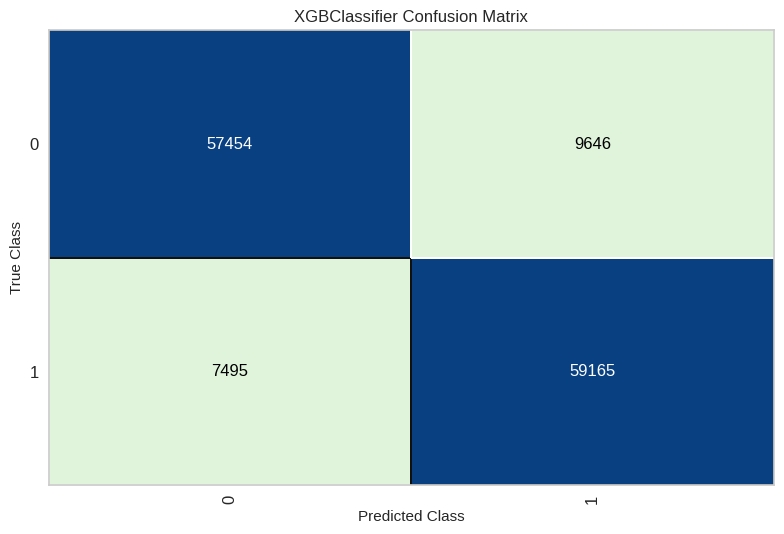

<Axes: title={'center': 'XGBClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [72]:
from yellowbrick.classifier import ConfusionMatrix
from xgboost import XGBClassifier

# Define and train the XGBoost classifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0)
#Initializes an XGBoost classifier with use_label_encoder=False (to suppress warnings) and eval_metric='logloss' (to use logarithmic loss as the evaluation metric),random_state=0 ensures reproducibility.


xgb_clf.fit(x_res_train, y_res_train)
# Trains the XGBoost classifier on the resampled training data (x_res_train, y_res_train)


xgb_cm = ConfusionMatrix(xgb_clf, Responses=Responses, cmap='GnBu')
# Creates a confusion matrix visualizer using the trained model.
#Responses=Responses should be replaced with the actual column name or list that corresponds to the response variable (the target column).


xgb_cm.score(x_res_test, y_res_test)
# Evaluate the model using the resampled test data (x_res_test, y_res_test)

# Displays the confusion matrix visualizationm
xgb_cm.show()

<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 11 | </span><span style='color:red'> XGBoost ROC-AUC Visualization
 </span></b>

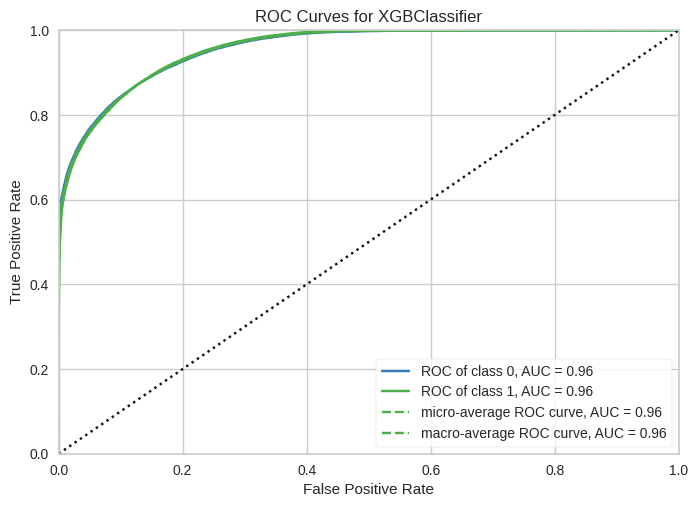

<Axes: title={'center': 'ROC Curves for XGBClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [73]:
from yellowbrick.classifier import ROCAUC
from xgboost import XGBClassifier
from yellowbrick.style import set_palette

# Define and train the XGBoost classifier

xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0)
# Initializes an XGBoost classifier with use_label_encoder=False (to avoid warnings), and eval_metric='logloss' (logarithmic loss as the evaluation metric), random_state=0 ensures reproducibility.

xgb_clf.fit(x_res_train, y_res_train)
# Trains the model using the resampled training data (x_res_train, y_res_train)

# Create the ROC AUC visualizer
visualizer = ROCAUC(xgb_clf, Responses=Responses)
# Replace Responses with the actual response variable name.

# Set a bold color palette
set_palette('bold')

# Fit the visualizer with the resampled training data.
visualizer.fit(x_res_train, y_res_train)        # Fit the training data to the visualizer

# Score the model on the test data
visualizer.score(x_res_test, y_res_test)        # Evaluate the model on the resampled test data

# Finalize and render the figure
visualizer.show()
# Displays the ROC AUC curve.

<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — XGBoost ROC-AUC Visualization:</font></h3>

<p>This code generates the ROC-AUC curve for the XGBoost model using the Yellowbrick library:</p>

<ul>
  <li>An <b>XGBClassifier</b> is trained on the SMOTE-resampled training data to ensure balanced learning.</li>

  <li>The <b>ROCAUC visualizer</b> plots the model’s ability to distinguish between the two classes (Response = 0 and 1).</li>

  <li><b>AUC score</b> indicates how well the model separates positive and negative classes — higher AUC means better classification performance.</li>

  <li>A bold color palette is applied for clearer visualization.</li>

  <li>The final plot shows the <b>True Positive Rate</b> vs <b>False Positive Rate</b>, helping evaluate model performance beyond accuracy.</li>
</ul>

<p>Overall, the ROC-AUC curve provides a strong visual measure of how effectively XGBoost identifies customers likely to respond to the insurance offer.</p>

</div>


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 12 | </span><span style='color:red'> Model Comparison
 </span></b>

#**Model Comparison:**

In [74]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC # Using LinearSVC as SVC is too slow on large datasets
from sklearn.metrics import classification_report
import numpy as np

# Ensure RANDOM_STATE is defined (it's defined in the initial imports cell)
# RANDOM_STATE = 42

print("Setting up models for comparison...")

# --- 1. Set consistent test sets for comparison (using SMOTE resampled test data) ---
X_test = x_res_test
y_test = y_res_test

# --- 2. Train and evaluate models on resampled data for fair comparison ---

# --- Logistic Regression ---
print("  Training Logistic Regression...")
lr_final = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='liblinear')
lr_final.fit(x_res_train, y_res_train)
lr_preds = lr_final.predict(X_test)
y_prob_lr = lr_final.predict_proba(X_test)[:, 1]
lr_report = classification_report(y_test, lr_preds, output_dict=True, zero_division=0)

# --- Decision Tree ---
print("  Training Decision Tree...")
dt_final = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_final.fit(x_res_train, y_res_train)
dt_preds = dt_final.predict(X_test)
y_prob_dt = dt_final.predict_proba(X_test)[:, 1]
dt_report = classification_report(y_test, dt_preds, output_dict=True, zero_division=0)

# --- Random Forest ---
print("  Training Random Forest...")
# Reduced n_estimators for slightly faster training for comparison purposes
rf_final = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, max_leaf_nodes=30)
rf_final.fit(x_res_train, y_res_train)
rf_preds = rf_final.predict(X_test)
y_prob_rf = rf_final.predict_proba(X_test)[:, 1]
rf_report = classification_report(y_test, rf_preds, output_dict=True, zero_division=0)



# --- AdaBoost ---
print("  Training AdaBoost...")
ada_final = AdaBoostClassifier(random_state=RANDOM_STATE)
ada_final.fit(x_res_train, y_res_train)
ada_preds = ada_final.predict(X_test)
y_prob_ada = ada_final.predict_proba(X_test)[:, 1]
ada_report = classification_report(y_test, ada_preds, output_dict=True, zero_division=0)

# --- XGBoost (re-training a new instance to ensure it's named `xgb_final` and for consistency) ---
print("  Training XGBoost...")
x_res_train.columns = [col.replace('<', 'less_than_').replace('>', 'greater_than_').replace('[', '_').replace(']', '_') for col in x_res_train.columns]
X_test.columns = [col.replace('<', 'less_than_').replace('>', 'greater_than_').replace('[', '_').replace(']', '_') for col in X_test.columns]
xgb_final = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_final.fit(x_res_train, y_res_train)
xgb_preds = xgb_final.predict(X_test)
y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]
xgb_report = classification_report(y_test, xgb_preds, output_dict=True, zero_division=0)

# --- 3. Construct results_df ---
results_data = []

def get_metrics_for_class_1(report_dict):
    return {
        "Accuracy": report_dict['accuracy'],
        "Precision": report_dict['1']['precision'],
        "Recall": report_dict['1']['recall'],
        "F1 Score": report_dict['1']['f1-score']
    }

results_data.append({"Model": "Logistic Regression", **get_metrics_for_class_1(lr_report)})
results_data.append({"Model": "Decision Tree", **get_metrics_for_class_1(dt_report)})
results_data.append({"Model": "Random Forest", **get_metrics_for_class_1(rf_report)})
results_data.append({"Model": "AdaBoost", **get_metrics_for_class_1(ada_report)})
results_data.append({"Model": "XGBoost", **get_metrics_for_class_1(xgb_report)})

results_df = pd.DataFrame(results_data)
print("\nResults DataFrame created:")
display(results_df)


Setting up models for comparison...
  Training Logistic Regression...
  Training Decision Tree...
  Training Random Forest...
  Training AdaBoost...
  Training XGBoost...

Results DataFrame created:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.826839,0.775723,0.917927,0.840855
1,Decision Tree,0.849073,0.842855,0.856916,0.849827
2,Random Forest,0.843743,0.788500,0.938074,0.856808
3,AdaBoost,0.834913,0.774292,0.943879,0.850717
4,XGBoost,0.871853,0.859819,0.887564,0.873471


<div style="border-radius:10px; padding: 12px; background-color: #ffe6d8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inference — Model Comparison:</font></h3>

<p>This code trains five different machine-learning models on the SMOTE-balanced dataset and compares their performance on the same test set:</p>

<ul>
  <li><b>Models Trained:</b> Logistic Regression, Decision Tree, Random Forest, AdaBoost, and XGBoost.</li>

  <li>Each model is fitted using the resampled training data (<b>x_res_train</b>, <b>y_res_train</b>) to ensure fair comparison on an equal class distribution.</li>

  <li>Predictions are generated for the resampled test set, and a classification report is computed for each model.</li>

  <li>Key metrics such as <b>Accuracy, Precision, Recall, and F1-Score (for class 1)</b> are extracted and stored in a results table.</li>

  <li>A final <b>results_df</b> DataFrame summarizes and displays all model performances side by side.</li>
</ul>

<p>Overall, this block helps identify the best-performing model for predicting customer response, making it easy to compare all algorithms using consistent metrics.</p>

</div>


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 13 | </span><span style='color:red'> Best Model Test & Train Score
 </span></b>

In [75]:
train_score = xgb_final.score(x_res_train, y_res_train)
test_score  = xgb_final.score(x_res_test, y_res_test)

print("\nXGBoost Model Performance:")
print(f"Train Score: {train_score:.4f}")
print(f"Test Score : {test_score:.4f}")



XGBoost Model Performance:
Train Score: 0.8773
Test Score : 0.8719


In [76]:
# 0. Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import set_config # Import set_config

# Set global configuration for transformer output to pandas
set_config(transform_output="pandas") # This ensures ColumnTransformer outputs DataFrames and expects DataFrame input when using string column names


RANDOM_STATE = 42

# --- Fix: Define df_fe and drop 'id' column ---
df_fe = df.copy() # Initialize df_fe from the existing 'df'
if 'id' in df_fe.columns:
    df_fe = df_fe.drop('id', axis=1)

# 1. Prepare X, y from your feature-engineered dataframe (df_fe)
#    Adjust these lists if your column names differ
#    The list comprehensions will filter out features not present in df_fe
numeric_features = [c for c in ['Age','Region_Code','Annual_Premium','Policy_Sales_Channel','Vintage','Annual_Premium_Log','Age_DL_Interaction','Premium_per_Vintage'] if c in df_fe.columns]
binary_features  = [c for c in ['Driving_License','Previously_Insured','High_Premium_Flag'] if c in df_fe.columns]
categorical_features = [c for c in ['Gender','Vehicle_Age','Vehicle_Damage'] if c in df_fe.columns]

features = numeric_features + binary_features + categorical_features
X = df_fe[features]     # Keep X as a DataFrame
y = df_fe['Response'].values

# 2. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
# train_test_split(X, y, ...): Splits the dataset into 80% training and 20% testing.

# 3. Preprocessing (ColumnTransformer) used inside pipeline
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Added sparse_output=False
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, numeric_features),
    ('bin', 'passthrough', binary_features),
    ('cat', cat_pipe, categorical_features)
])

# 4. Model pipeline (preprocessing + logistic regression)
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='liblinear'))
])

# 5. Stratified K-Fold Cross Validation (before final training)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
print("CV Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# 6. Train final pipeline on train set (after CV)
pipe.fit(X_train, y_train)

# 7. Test accuracy (PRINTED LAST)
y_test_pred = pipe.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)


CV Accuracy Scores: [0.87743696 0.87735824 0.8774632  0.87743696 0.87740911]
Mean CV Accuracy: 0.8774208953034897
Test Accuracy: 0.8774369604576107


<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 14 | </span><span style='color:red'> Save The Model:
 </span></b>

In [77]:
# Import necessary libraries for data manipulation (pandas, numpy), preprocessing (LabelEncoder, MinMaxScaler, SimpleImputer), handling class imbalance (SMOTE),
# machine learning (XGBClassifier), and saving the model (joblib).

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier
from joblib import dump
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.impute import SimpleImputer

# Load data
df = pd.read_csv("/content/drive/MyDrive/Insurance_Response.csv")

# Drop unnecessary column
df.drop(columns=["id"], axis=1, inplace=True)

#Converts Vehicle_Damage into numerical values: Yes ? 1, No ? 0
df["Vehicle_Damage"].replace(to_replace="Yes",value=1,inplace=True)
df["Vehicle_Damage"].replace(to_replace="No",value=0,inplace=True)

#Encodes Gender and Vehicle_Age using LabelEncoder to turn categorical values into numbers (e.g., Male/Female ? 1/0)
label_encoder = LabelEncoder()
df["Gender"] = label_encoder.fit_transform(df["Gender"])# Male=1, Female=0
df["Vehicle_Age"] = label_encoder.fit_transform(df["Vehicle_Age"])


df_dummies=pd.get_dummies(df)
# Creates dummy variables for categorical features, turning them into a one-hot encoded format.

x = df.drop(['Response'], axis = 1)
y = df.loc[:,'Response'].values
# Separates the dataset into x (features) and y (target variable Response)

x.dropna(inplace=True)
# Drops rows in x with missing values.

imputer = SimpleImputer(strategy='mean') # Choose a strategy: 'mean', 'median', 'most_frequent'


# Impute missing values in 'x' before dropping rows in 'y'
x = imputer.fit_transform(x)

# Now, align 'y' with 'x' after imputation:
x = pd.DataFrame(x)  # Convert x back to DataFrame for indexing
x.reset_index(drop=True, inplace=True) # Reset index of x
# Converts x back to a DataFrame and resets its index
y = y[x.index]  # Ensures y aligns with x after imputation.

# Now apply SMOTE
sm = SMOTE(random_state=42)
# Uses SMOTE (Synthetic Minority Oversampling Technique) to balance the dataset by oversampling the minority class.

# Use 'x' instead of 'X' as input to fit_resample
x_res, y_res = sm.fit_resample(x, y)

# Train the Model
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_res, y_res)
# Trains the model using the oversampled dataset (x_res, y_res).


# Save the trained model
dump(model, 'insurance_model_sm.joblib')  # Saves the trained model to a file (insurance_model_sm.joblib) for later use.

['insurance_model_sm.joblib']

<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 15 | Conclusion </span><span style='color:red'>

 </span></b>

<div style="border-radius:10px; padding: 15px; background-color: #fde0d9; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Conclusion:</font></h3>

<p>
After evaluating multiple machine-learning models—including Logistic Regression, Decision Tree, Random Forest, AdaBoost, and XGBoost—the analysis clearly shows that <b>XGBoost</b> delivers the best overall performance for predicting customer response to insurance offers.
</p>

<ul>
  <li><b>Highest Accuracy:</b> XGBoost achieved an accuracy of <b>87.18%</b>, outperforming all other models.</li>

  <li><b>Strong Precision & Recall:</b> With a precision of <b>0.8598</b> and recall of <b>0.8875</b>, it effectively identifies customers who are likely to respond while minimizing false positives.</li>

  <li><b>Best F1-Score:</b> The highest F1 score of <b>0.8735</b> indicates that it provides the most balanced and reliable predictions for the imbalanced dataset.</li>

  <li><b>Works Well with Imbalanced Data:</b> Compared to other models, XGBoost handles complex patterns and class imbalance more effectively—especially after applying SMOTE.</li>
</ul>

<p>
Overall, <b>XGBoost is the recommended final model</b> for deployment, as it offers the most accurate and dependable predictions. This model can help the insurance company identify potential customers more efficiently, improve targeted marketing efforts, and increase conversion rates.
</p>

</div>
